# Explainer Notebook - NYC Vehicle Collisions

In this notebook we have chosen to include more plots than those shown on the website, in order to document the full work process and demonstrate that the analysis extends beyond what is directly presented. All plots can be found in the data analysis section, which is divided into two parts: an exploratory and statistical analysis section, and a machine learning section.
The plots in this notebook are not identical to those on the website in terms of layout. However, this is intentional. For the website, plots are exported to HTML with transparent backgrounds, no titles, and slightly different colours to match the site's visual design. In the notebook, we have kept titles and a white background for readability. The underlying analysis and data are identical in both cases.
We also chose not to include every single plot on the website, as this would overwhelm the narrative. The website shows the most accessible and story-relevant findings, while the notebook contains the full analytical foundation behind them.



# 1. Motivation

For this project, several datasets have been utilized to effectively analyze vehicle collisions in New York City. They are all publicly available via the NYC Open Data portal and maintained by the New York City Police Department (NYPD). The different datasets are:

<a href="https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/about_data">Motor Vehicle Collisions - Crashes</a>

Each row in this dataset represents a crash event, featuring 29 variables that describe the collision. These include date and time, various geospatial data points—such as latitude, longitude, and borough—and details on injuries and fatalities categorized by pedestrians, cyclists, and motorists. This dataset is specifically well-suited for distinguishing between individual crashes and conducting geographic analysis. It serves as the primary dataset for all machine learning-based analysis.

<a href="https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Vehicles/bm4k-52h4/about_data">Motor Vehicle Collisions - Vehicles</a>

Each row in this dataset represents a motor vehicle involved in a crash. Each vehicle involved is described by 25 different variables, detailing attributes such as vehicle type, pre-crash action, and contributing factors. This dataset has been used to more easily distinguish each vehicle involved, independently of the crash itself.


<a href="https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Person/f55k-p6yu/about_data">Motor Vehicle Collisions - Persons</a>

Each row in this dataset represents a person (driver, occupant, pedestrian, or bicyclist) involved in a crash. Each entry is described by 21 variables, including injury status, age, sex, and specific pedestrian locations and actions. This dataset has been valuable for analyzing patterns among individuals, independent of the specific crash event.

The three above-mentioned datasets also contain a shared variable: a Collision ID. This ID binds them together, making it possible to merge the data and conduct analysis across all three datasets.

<a href="https://data.cityofnewyork.us/Transportation/Automated-Traffic-Volume-Counts/7ym2-wayt/about_data">Automated Traffic Volume Counts</a>

The data in this dataset is collected by the New York City Department of Transportation (NYC DOT). They utilize Automated Traffic Recorders (ATR) to collect traffic volume counts at bridge crossings and roadways. Each row represents a unique count across 14 variables. These include geographic variables such as borough and street, the date and time of the sample count, and - crucially - the volume variable, which represents the total sum of counts collected in 15-minute increments. This dataset was included to illustrate how traffic density is an important underlying factor in traffic collisions.

<a href="https://data.cityofnewyork.us/City-Government/DSNY-Salt-Usage/tavr-zknk/about_data">DSNY Salt Usage</a>

This dataset details the amount of salt the NYC Department of Sanitation (DSNY) dispenses from salt sites during the snow season. Each row represents a day and contains eight variables, including the tonnage of salt used, the borough, and the report date. This dataset has been brought into the analysis to identify underlying patterns of vehicle collisions related to weather conditions.

#### The goal for the end user's experience:
The goal for the end-user experience is to provide an insightful understanding of vehicle collisions in New York City, with a particular focus on fatalities caused by various factors. Furthermore, the project aims to showcase how these collisions impact individuals differently depending on their mode of transport—whether they are a pedestrian, motorist, or cyclist. By doing so, the narrative is presented in an interactive and engaging way, allowing the reader to feel in control and more invested in the story. A more fundamental goal is to demonstrate through data that these crashes are not merely accidents; they are collisions caused by a complex set of variables. This perspective enables targeted governmental actions toward prevention, such as the Vision Zero initiative, where data plays a crucial role in driving safety measures.

# 2. Basic Stats

### Data Cleaning and Preprocessing 

To ensure relevence for our specific goals thorugh out the data analysis, we performed several targeted cleaning and preprocessing steps across the datasets, especially important are

**Spatial Data Filtering**: For our geographic and machine learning analysis, DBSCAN, accurate location data is strictly necessary. We identified and removed records with missing `LATITUDE` and `LONGITUDE` values, as well as those with coordinates set to (0.0, 0.0), which are clear placeholder errors. 

**Demographic Standardization**: We cleaned the PERSON_AGE variable by filtering out unrealistic values (e.g., setting the valid range strictly between 1 and 110 years), as '0' appears to be used as a placeholder for unknown ages in the reporting. Additionally, unspecified values in `PERSON_SEX` (marked as 'U') were converted to NaN to prevent skewed demographic distributions.

**Temporal Features**: To handle the temporal data effectively, we utilized the Pandas `to_datetime` function to parse and combine the `CRASH DATE` and `CRASH TIME` strings into unified datetime objects when necessary in the three datasets Crashes, Vehicles and Persons. This precise conversion allowed us to extract time-based features such as the specific `HOUR` of the day and the `MONTH` enabling temporal visualizations.

**Basic Formatting**: To ensure seamless data manipulation and prevent unexpected syntax errors, we standardized the column headers across our primary datasets. This involved systematically stripping hidden leading and trailing whitespaces from all column names and replacing spaces with underscores (e.g., standardizing `CRASH DATE` to `CRASH_DATE` in the `CRASHES` dataset). 

### Preliminary stats and exploring the datasets



In [15]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math

In [16]:
# Read the data
SALT = pd.read_csv("DSNY_Salt_Usage_20260428.csv")
COUNT = pd.read_csv("Automated_Traffic_Volume_Counts_20260429.csv")
CRASHES = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes_20260407.csv")      
PERSONS = pd.read_csv("Motor_Vehicle_Collisions_-_Person_20260428.csv")   
VEHICLES = pd.read_csv('Motor_Vehicle_Collisions_-_Vehicles_20260428.csv')


C:\Users\frida\AppData\Local\Temp\ipykernel_41864\3116433501.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  CRASHES = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes_20260407.csv")
C:\Users\frida\AppData\Local\Temp\ipykernel_41864\3116433501.py:6: DtypeWarning: Columns (8,11) have mixed types. Specify dtype option on import or set low_memory=False.
  VEHICLES = pd.read_csv('Motor_Vehicle_Collisions_-_Vehicles_20260428.csv')


In [17]:
# Adding underscores to column names in CRASHES
CRASHES.columns = CRASHES.columns.str.replace(' ', '_')

# Basic Formatting
PERSONS.columns = PERSONS.columns.str.strip()
CRASHES.columns = CRASHES.columns.str.strip()
VEHICLES.columns = VEHICLES.columns.str.strip()
SALT.columns = SALT.columns.str.strip()

A summary below establishes a clear baseline of our datasets' scale, temporal coverage, and quality. The data is massive, spanning millions of records since 2012, and immediately highlights our core motivation: nearly 10% of all unique collisions involve vulnerable pedestrians or cyclists. Additionally, quantifying the missing spatial information — such as the 11% of crashes lacking exact coordinates and 31% missing borough data — directly justifies the critical filtering steps. 

Because the original datasets contain millions of records, focusing on specific sub-groups (like pedestrians and cyclists) or filtering out missing spatial values still leaves us with a vast amount of usable data. Consequently, these reductions do not compromise the statistical power of our analysis, ensuring our findings remain robust.

In [18]:

# Function to print section headers
def print_section_header(title):
    print(f"\n{'='*60}")
    print(f"{title.upper():^60}")
    print(f"{'='*60}")

# Convert date columns to datetime format for all datasets
# COUNT is handled separately since it has separate Yr, M, D columns
CRASHES['CRASH_DATE'] = pd.to_datetime(CRASHES['CRASH_DATE'])
VEHICLES['CRASH_DATE'] = pd.to_datetime(VEHICLES['CRASH_DATE'])
PERSONS['CRASH_DATE'] = pd.to_datetime(PERSONS['CRASH_DATE'])
SALT['Date of Report'] = pd.to_datetime(SALT['Date of Report'])
COUNT_DATES = pd.to_datetime(COUNT[['Yr', 'M', 'D']].rename(columns={'Yr': 'year', 'M': 'month', 'D': 'day'}))

# Dataset Overview & Temporal Range
print_section_header("Dataset Overview & Temporal Range")
header = f"{'Dataset':<20} | {'Rows':<12} | {'Start Date':<12} | {'End Date':<12}"
print(header)
print("-" * len(header))

datasets = [
    ("CRASHES", CRASHES, CRASHES['CRASH_DATE']),
    ("VEHICLES", VEHICLES, VEHICLES['CRASH_DATE']),
    ("PERSONS", PERSONS, PERSONS['CRASH_DATE']),
    ("SALT", SALT, SALT['Date of Report']),
    ("TRAFFIC COUNT", COUNT, COUNT_DATES)
]

for name, df, date_col in datasets:
    start = date_col.min().strftime('%Y-%m-%d')
    end = date_col.max().strftime('%Y-%m-%d')
    print(f"{name:<20} | {len(df):<12,} | {start:<12} | {end:<12}")

# Involvement of Pedestrians and Cyclists
print_section_header("Pedestrian & Cyclist Involvement")

total_unique_crashes = CRASHES['COLLISION_ID'].nunique()

# From PERSONS, find unique COLLISION_IDs for pedestrians and cyclists
ped_ids = PERSONS[PERSONS['PERSON_TYPE'] == 'Pedestrian']['COLLISION_ID'].unique()
cyc_ids = PERSONS[PERSONS['PERSON_TYPE'] == 'Bicyclist']['COLLISION_ID'].unique()

ped_pct = (len(ped_ids) / total_unique_crashes) * 100
cyc_pct = (len(cyc_ids) / total_unique_crashes) * 100

print(f"Total Unique Collisions: {total_unique_crashes:,}")
print(f"Crashes involving Pedestrians: {len(ped_ids):<8,} ({ped_pct:.2f}%)")
print(f"Crashes involving Cyclists:    {len(cyc_ids):<8,} ({cyc_pct:.2f}%)")

# Missing values in spatial information
print_section_header("Data Quality (Missing Spatial Info)")
missing_borough = CRASHES['BOROUGH'].isna().sum()
missing_coords = CRASHES['LATITUDE'].isna().sum()

print(f"{'Missing Boroughs:':<25} {missing_borough:<10,} ({missing_borough/len(CRASHES)*100:.2f}%)")
print(f"{'Missing Coordinates:':<25} {missing_coords:<10,} ({missing_coords/len(CRASHES)*100:.2f}%)")


             DATASET OVERVIEW & TEMPORAL RANGE              
Dataset              | Rows         | Start Date   | End Date    
-----------------------------------------------------------------
CRASHES              | 2,253,192    | 2012-07-01   | 2026-04-03  
VEHICLES             | 4,528,736    | 2012-07-01   | 2026-04-24  
PERSONS              | 5,945,665    | 2012-07-01   | 2026-04-24  
SALT                 | 224          | 2016-01-19   | 2026-02-22  
TRAFFIC COUNT        | 1,875,154    | 2000-01-01   | 2026-02-03  

              PEDESTRIAN & CYCLIST INVOLVEMENT              
Total Unique Collisions: 2,253,192
Crashes involving Pedestrians: 140,209  (6.22%)
Crashes involving Cyclists:    77,436   (3.44%)

            DATA QUALITY (MISSING SPATIAL INFO)             
Missing Boroughs:         687,462    (30.51%)
Missing Coordinates:      240,676    (10.68%)


Before advancing to the main data analysis, these are some initial vizualisations to explore some of the ways to group the data to understand its complexity. A central focus of our overall analysis is understanding crash severity and the specific factors that lead to fatal outcomes. These initial plots highlight several critical insights:

**The Macro Trend**: The annual development shows a drop in total crashes in 2020, highly likely due to COVID-19 lockdowns. Interestingly, this period also coincides with a spike in the fatality rate. While our general knowledge suggests that empty streets led to higher speeds — making the crashes more lethal — this remains a hypothesis that cannot be proven with absolute certainty from this dataset alone.

**Unequal Vulnerability**: Directly addressing our focus on fatalities, the road user category plot exposes a stark contrast in risk. Vulnerable road users — particularly pedestrians — face a disproportionately higher risk of death upon collision compared to enclosed motorists.

**Demographic Profiles**: The age and sex distribution clearly identifies the specific populations most frequently involved in these incidents.

**Temporal Rhythms**: The hourly collision frequency reveals a highly structured, non-random daily pattern.

Ultimately, these combined insights suggest that crashes and especially their fatal outcomes are not random, but are driven by underlying systemic variables. This exploration sets the stage for the subsequent data analysis sections, where we will investigate the data in more depth to better understand the true anatomy of NYC traffic collisions.

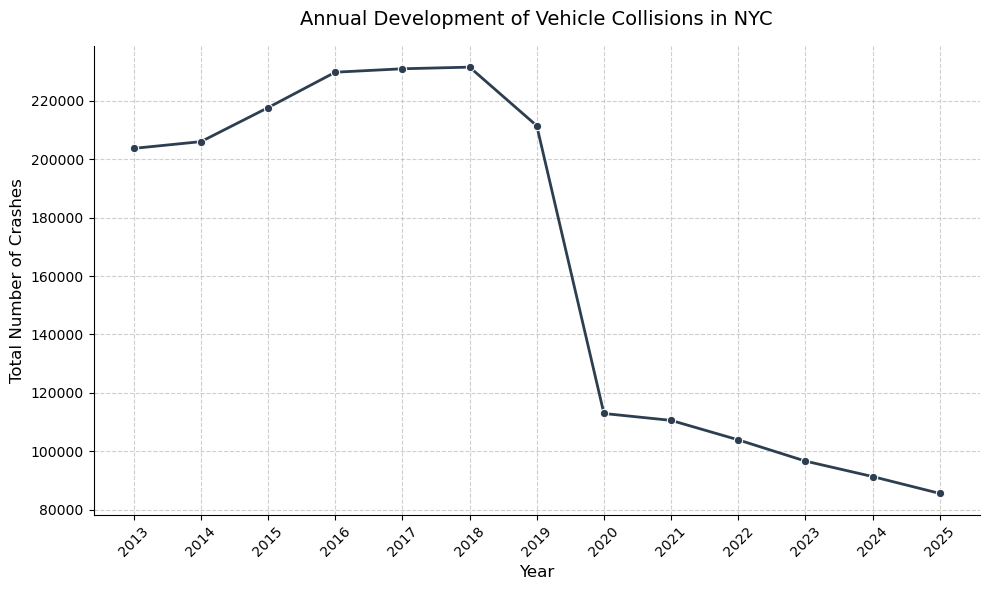

In [19]:
# Make column for year
CRASHES['YEAR'] = CRASHES['CRASH_DATE'].dt.year

# filter to only have full years (2013-2025)
CRASHES_filtered = CRASHES[CRASHES['YEAR'].between(2013, 2025)].copy()
# number of crashes per year
yearly_crashes = CRASHES_filtered.groupby('YEAR').size()

# Plotting 
plt.figure(figsize=(10, 6))
sns.lineplot(
    x=yearly_crashes.index, 
    y=yearly_crashes.values, 
    marker='o', 
    color='#2c3e50',
    linewidth=2.0,
    markersize=6
)

# Titles and labels
plt.title('Annual Development of Vehicle Collisions in NYC', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Number of Crashes', fontsize=12)

# whole numbers on x-axis
plt.xticks(yearly_crashes.index, rotation=45)

# grid, style and layout
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.show()

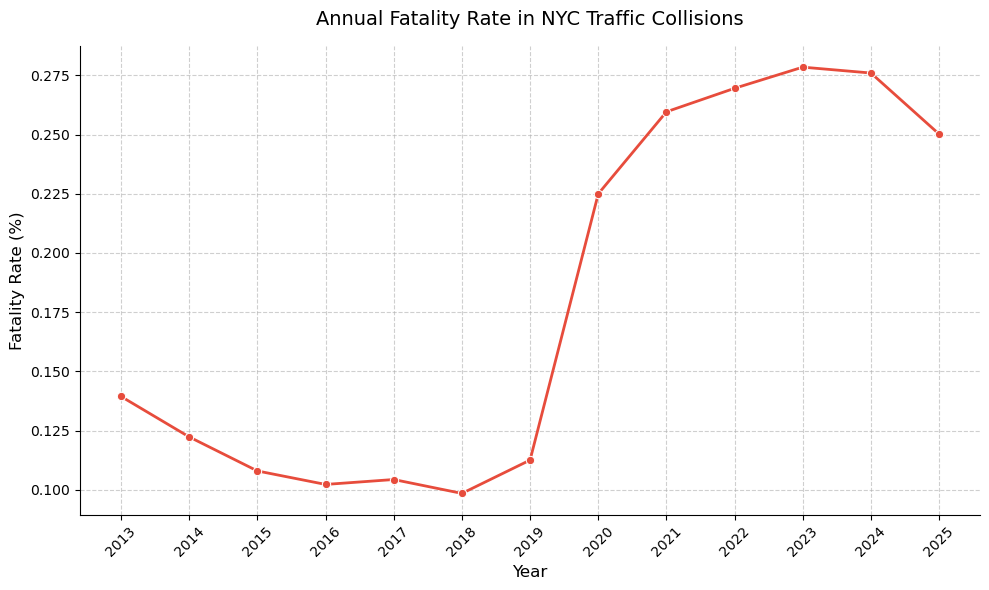

In [20]:

# Create boolean flag: True if anyone was killed, False otherwise
CRASHES_filtered['IS_FATAL'] = CRASHES_filtered['NUMBER_OF_PERSONS_KILLED'] > 0

# Calculate annual fatality rate (%) using the mean of the boolean flag
fatality_rate = CRASHES_filtered.groupby('YEAR')['IS_FATAL'].mean() * 100

# Initialize plot
plt.figure(figsize=(10, 6))

# Plot the fatality rate with a distinct color (e.g., red for fatalities)
sns.lineplot(
    x=fatality_rate.index, 
    y=fatality_rate.values, 
    marker='o', 
    color='#e74c3c', 
    linewidth=2.0,
    markersize=6
)

# Format plot aesthetics
plt.title('Annual Fatality Rate in NYC Traffic Collisions', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Fatality Rate (%)', fontsize=12)

# Ensure all years are shown as integers on the x-axis
plt.xticks(fatality_rate.index, rotation=45)

# Add grid and clean up borders
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.show()

Distribution of Road Users:
USER_CATEGORY
Motorist      5705877
Pedestrian     146845
Cyclist         80215
Name: count, dtype: int64
------------------------------
Fatality Rate (%) by Category:
USER_CATEGORY
Cyclist       0.359035
Motorist      0.025518
Pedestrian    1.220334
Name: IS_FATAL, dtype: float64


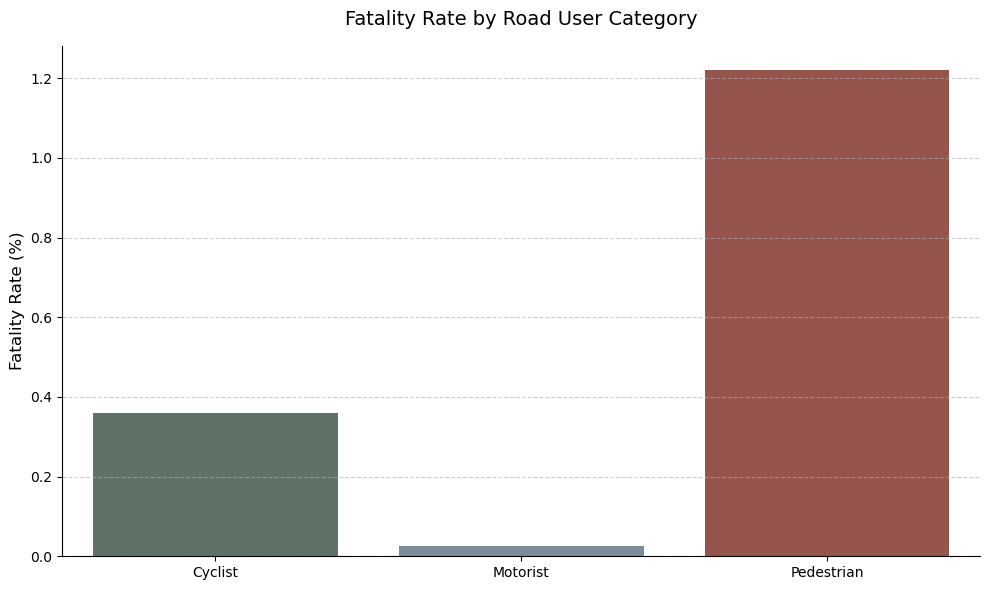

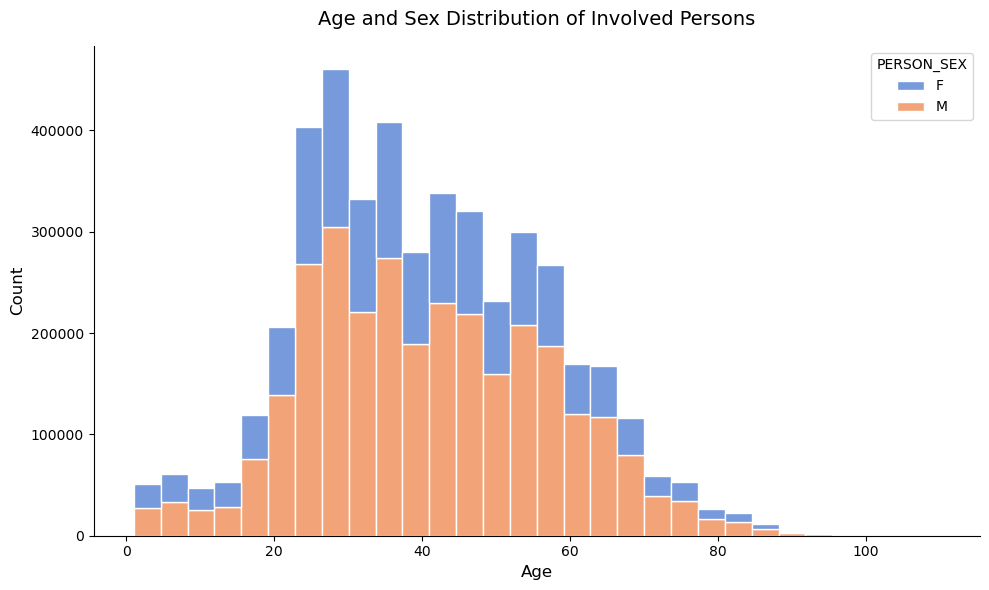

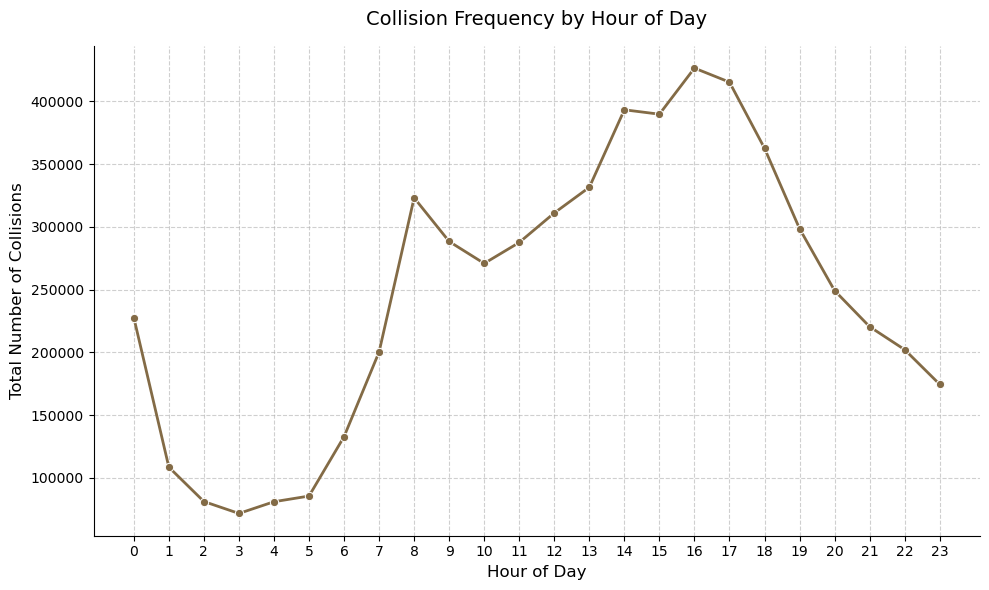

In [21]:
# Extract temporal features
PERSONS['HOUR'] = pd.to_datetime(PERSONS['CRASH_TIME'], format='%H:%M', errors='coerce').dt.hour
PERSONS['MONTH'] = PERSONS['CRASH_DATE'].dt.month_name()

# Clean demographic data (Age and Sex)
PERSONS['PERSON_AGE'] = pd.to_numeric(PERSONS['PERSON_AGE'], errors='coerce')

# Filter out unrealistic ages (0 is a known placeholder for "unknown")
PERSONS.loc[~PERSONS['PERSON_AGE'].between(1, 110), 'PERSON_AGE'] = np.nan

# Standardize sex column by replacing 'U' (Unspecified) with NaN
PERSONS['PERSON_SEX'] = PERSONS['PERSON_SEX'].replace({'U': np.nan})

# Categorize road users into primary types
def categorize_person(p_type):
    p_type = str(p_type).lower()
    if 'pedestrian' in p_type: return 'Pedestrian'
    if 'bicyclist' in p_type: return 'Cyclist'
    if 'occupant' in p_type: return 'Motorist'
    return 'Other'

PERSONS['USER_CATEGORY'] = PERSONS['PERSON_TYPE'].apply(categorize_person)

# Filter dataset to only include primary road users
PERSONS_CLEAN = PERSONS[PERSONS['USER_CATEGORY'] != 'Other'].copy()

# Print distribution overview
print("Distribution of Road Users:")
print(PERSONS_CLEAN['USER_CATEGORY'].value_counts())
print("-" * 30)

# Calculate fatality rate per category
PERSONS_CLEAN['IS_FATAL'] = PERSONS_CLEAN['PERSON_INJURY'] == 'Killed'
fatality_rate = PERSONS_CLEAN.groupby('USER_CATEGORY')['IS_FATAL'].mean() * 100

print("Fatality Rate (%) by Category:")
print(fatality_rate)


# ==========================================
# PLOT 1: Fatality Rate by Category
# ==========================================
plt.figure(figsize=(10, 6))

# Map specific colors to categories for visual consistency
category_colors = {'Pedestrian': "#a14a40", 'Cyclist': "#5b7566", 'Motorist': "#768e9e"}

sns.barplot(
    x=fatality_rate.index, 
    y=fatality_rate.values, 
    hue=fatality_rate.index,
    palette=category_colors,
    legend=False
)

plt.title('Fatality Rate by Road User Category', fontsize=14, pad=15)
plt.ylabel('Fatality Rate (%)', fontsize=12)
plt.xlabel('') # Left blank as categories are self-explanatory

plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.show()


# ==========================================
# PLOT 2: Demographic Distribution
# ==========================================
plt.figure(figsize=(10, 6))

sns.histplot(
    data=PERSONS_CLEAN, 
    x='PERSON_AGE', 
    hue='PERSON_SEX', 
    multiple="stack", 
    bins=30,
    edgecolor='white',
    palette='muted'
)

plt.title('Age and Sex Distribution of Involved Persons', fontsize=14, pad=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()


# ==========================================
# PLOT 3: Temporal Patterns (Hour of Day)
# ==========================================
hourly_counts = PERSONS_CLEAN.groupby('HOUR').size()

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=hourly_counts.index, 
    y=hourly_counts.values, 
    marker='o', 
    color="#836B46", 
    linewidth=2.0, 
    markersize=6
)

plt.title('Collision Frequency by Hour of Day', fontsize=14, pad=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Total Number of Collisions', fontsize=12)

plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.show()

# 3. Data Analysis

Through the analysis of several datasets, a distinction emerges between the frequency of crashes and their actual lethality. While the total volume of collisions aligns with daily rush hours and seasonal patterns, normalizing the data against traffic counts reveals specific risk zones. For instance, there is an elevated danger in the early morning hours, where motorist crashes exceed what baseline traffic volumes would predict. Environmental factors also play a role; winter storm days (indicated by salt usage) correspond with an increase in average daily crashes for motorists, while incidents involving pedestrians and cyclists decrease, likely due to reduced physical exposure rather than inherently safer conditions.

Demographically, the dataset highlights differences in traffic risk and physical vulnerability. Young adult males represent the largest group involved in overall collisions, and male involvement consistently correlates with a higher fatality rate across all modes of transport. However, the most notable disparity appears among road user categories. Enclosed motorists account for the vast majority of crashes, but pedestrians bear a disproportionate share of fatal outcomes. This vulnerability compounds with age; the fatality rate for pedestrians over 65 increases noticeably compared to younger demographics, indicating that physical fragility is a key factor in crash survivability.

When analyzing root causes and vehicle types, a pattern of "common versus deadly" becomes evident. Driver inattention and distraction are the most frequent contributing factors citywide. Yet, when examining fatality rates, behaviors such as unsafe speed, alcohol involvement, and disregarded traffic controls prove to be much more lethal. A similar dynamic exists among vehicles. Passenger vehicles and SUVs naturally dominate total crash volumes, but collisions involving heavy commercial vehicles, like box trucks and buses, show higher lethality rates when pedestrians and cyclists are hit. Additionally, physical dynamics—such as a user's ejection status during a crash or high-risk pedestrian actions like walking along a highway—strongly influence the severity of the outcome.

Ultimately, both the exploratory analysis and our machine learning models indicate that traffic fatalities are predictable events driven by specific variables rather than purely random accidents. Our predictive models performed well—particularly for motorist fatalities by relying on critical features such as ejection status, victim age, hour of the day, and primary vehicle type. By mapping these complex relationships, the analysis demonstrates that severe crashes are systemic issues. This insight supports the core premise of initiatives like Vision Zero: by using data to address the most lethal factors such as speed, heavy vehicle interactions, and vulnerable demographic patterns, traffic fatalities can be better understood and prevented.

Note that the statistical data analysis and the machine learning components was conducted on separate computers, which is why the datasets are loaded differently throughout the notebook. This has no effect on the analysis or results.

## Statistical Data Analysis

### Temporal Patterns

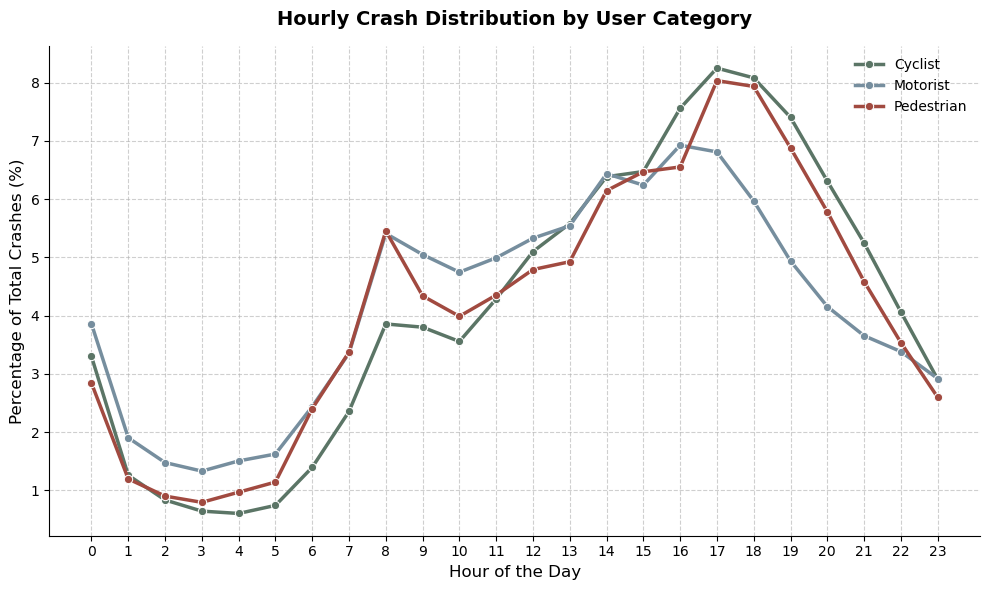

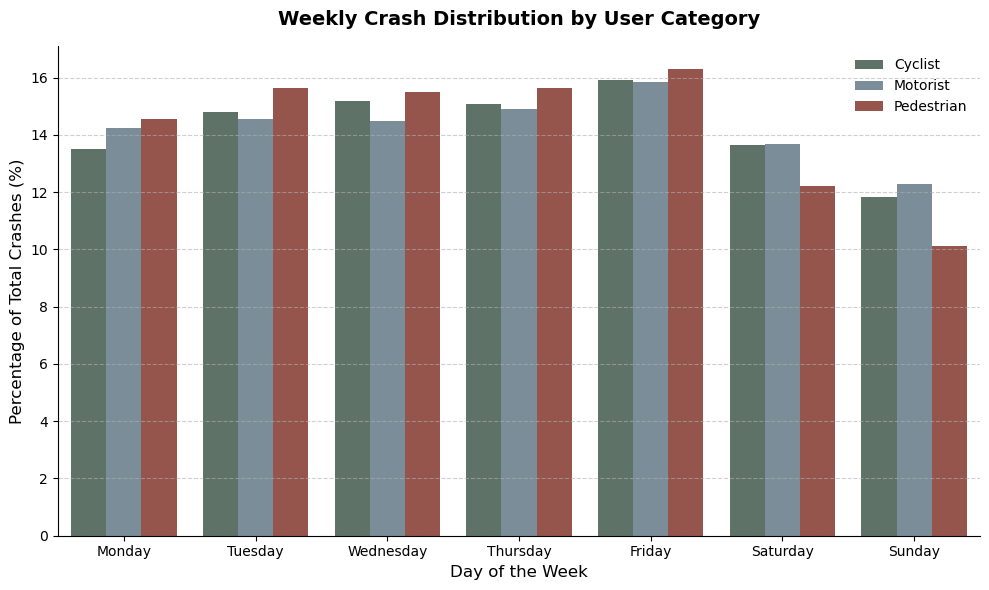

In [22]:
# Extract day of the week for the weekly analysis
PERSONS_CLEAN['DAY_OF_WEEK'] = PERSONS_CLEAN['CRASH_DATE'].dt.day_name()

# Drop duplicate collision IDs per category to avoid overcounting 
unique_crashes = PERSONS_CLEAN.drop_duplicates(subset=['COLLISION_ID', 'USER_CATEGORY'])

# Re-establish the consistent color palette used in previous plots
category_colors = {'Pedestrian': "#a14a40", 'Cyclist': "#5b7566", 'Motorist': "#768e9e"}

# ==========================================
# PLOT 1: HOURLY TRENDS
# ==========================================

# Calculate crash counts per hour for each user category
hourly_counts = unique_crashes.groupby(['USER_CATEGORY', 'HOUR']).size().reset_index(name='count')

# Get the total crashes per category to calculate percentages
total_per_type = unique_crashes.groupby('USER_CATEGORY').size().reset_index(name='total')
hourly_merged = hourly_counts.merge(total_per_type, on='USER_CATEGORY')

# Calculate the relative percentage
hourly_merged['percentage'] = (hourly_merged['count'] / hourly_merged['total']) * 100

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=hourly_merged, 
    x='HOUR', 
    y='percentage', 
    hue='USER_CATEGORY', 
    palette=category_colors,
    marker='o', 
    linewidth=2.5
)

plt.title('Hourly Crash Distribution by User Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Percentage of Total Crashes (%)', fontsize=12)

plt.xticks(range(0, 24))
plt.legend(title='', frameon=False) # Clean legend without a box
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()

plt.show()


# ==========================================
# PLOT 2: DAY OF WEEK TRENDS
# ==========================================

# Define logical order for the x-axis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate crash counts per day of the week for each user category
daily_counts = unique_crashes.groupby(['USER_CATEGORY', 'DAY_OF_WEEK']).size().reset_index(name='count')
daily_merged = daily_counts.merge(total_per_type, on='USER_CATEGORY')

# Calculate the relative percentage
daily_merged['percentage'] = (daily_merged['count'] / daily_merged['total']) * 100

plt.figure(figsize=(10, 6))

sns.barplot(
    data=daily_merged, 
    x='DAY_OF_WEEK', 
    y='percentage', 
    hue='USER_CATEGORY', 
    order=day_order, 
    palette=category_colors
)

plt.title('Weekly Crash Distribution by User Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Percentage of Total Crashes (%)', fontsize=12)

plt.legend(title='', frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()

plt.show()

### Seasonality and Weather

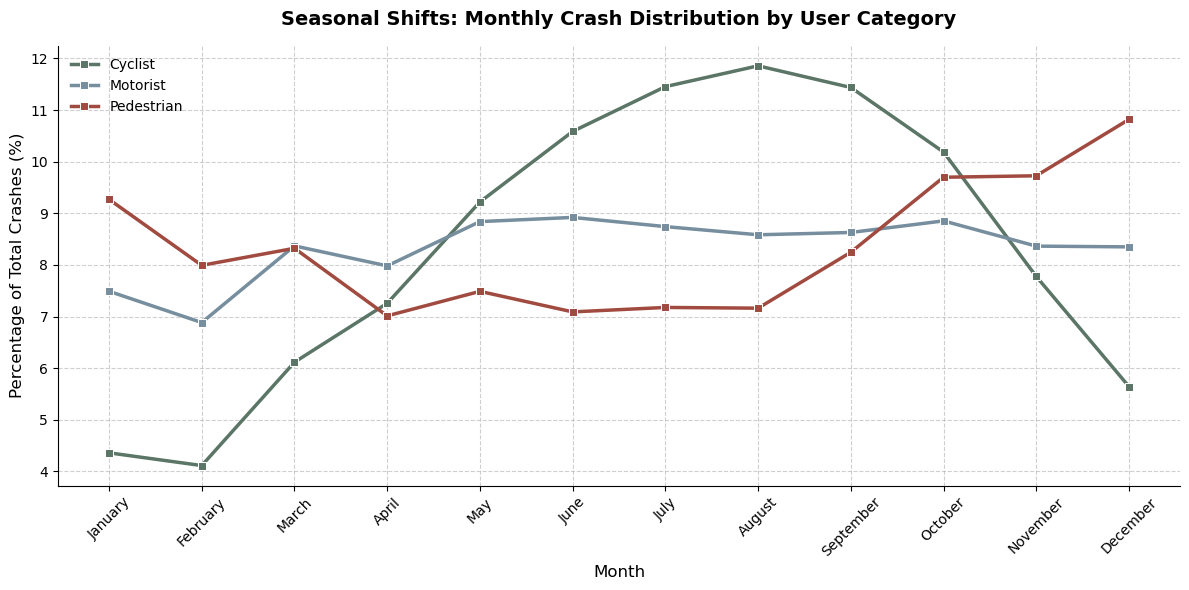

C:\Users\frida\AppData\Local\Temp\ipykernel_41864\2414168283.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_crashes['CRASH_DATE_ONLY'] = unique_crashes['CRASH_DATE'].dt.normalize()


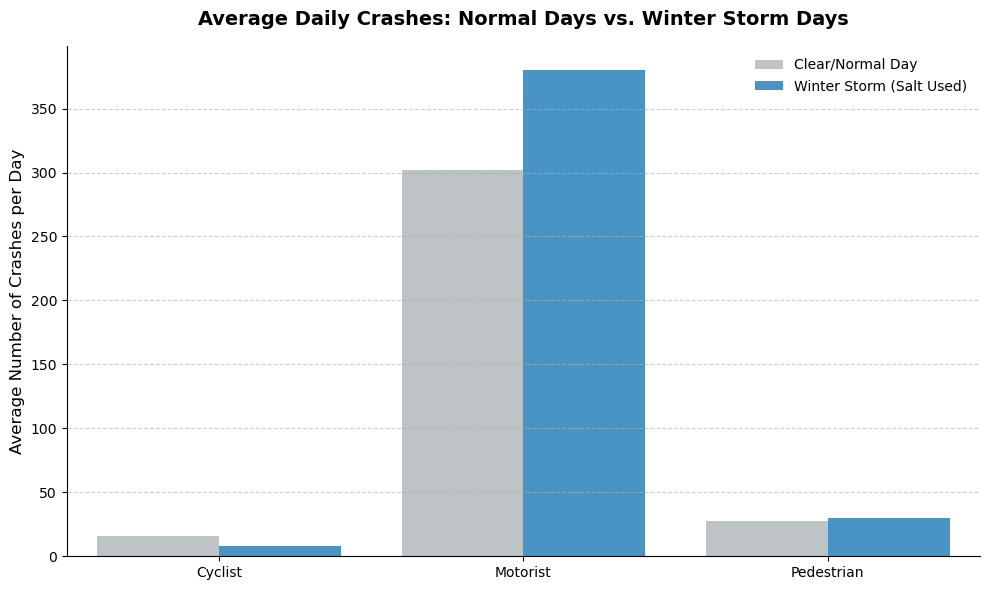

In [23]:
# ==========================================
# PLOT 3: MONTHLY TRENDS
# ==========================================

# Define the chronological order for months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Calculate crash counts per month for each user category
monthly_counts = unique_crashes.groupby(['USER_CATEGORY', 'MONTH']).size().reset_index(name='count')
monthly_merged = monthly_counts.merge(total_per_type, on='USER_CATEGORY')

# Calculate the relative percentage
monthly_merged['percentage'] = (monthly_merged['count'] / monthly_merged['total']) * 100

# Apply chronological order to the month column and sort
monthly_merged['MONTH'] = pd.Categorical(monthly_merged['MONTH'], categories=month_order, ordered=True)
monthly_merged = monthly_merged.sort_values('MONTH')

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_merged, 
    x='MONTH', 
    y='percentage', 
    hue='USER_CATEGORY', 
    palette=category_colors,
    marker='s', 
    linewidth=2.5
)

plt.title('Seasonal Shifts: Monthly Crash Distribution by User Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Percentage of Total Crashes (%)', fontsize=12)

plt.xticks(rotation=45)
plt.legend(title='', frameon=False)
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()

plt.show()


# ==========================================
# PLOT 4: THE WEATHER EFFECT
# ==========================================

# Aggregate total salt used per day
# Ensure SALT date is a datetime object
SALT['Date of Report'] = pd.to_datetime(SALT['Date of Report'])
daily_salt = SALT.groupby('Date of Report')['Total Tons'].sum().reset_index()

# Normalize CRASH_DATE to ensure it only contains the date (no time component) for merging
unique_crashes['CRASH_DATE_ONLY'] = unique_crashes['CRASH_DATE'].dt.normalize()

# Count true unique crashes per day for each user category
daily_unique_crashes = unique_crashes.groupby(['CRASH_DATE_ONLY', 'USER_CATEGORY']).size().reset_index(name='daily_crash_count')

# Merge daily crash counts with salt data
weather_crashes = daily_unique_crashes.merge(daily_salt, left_on='CRASH_DATE_ONLY', right_on='Date of Report', how='left')

# Fill missing salt values with 0 and define weather conditions
weather_crashes['Total Tons'] = weather_crashes['Total Tons'].fillna(0)
weather_crashes['Weather_Condition'] = np.where(
    weather_crashes['Total Tons'] > 0, 
    'Winter Storm (Salt Used)', 
    'Clear/Normal Day'
)

# Calculate the average number of unique crashes per day type
avg_crashes_weather = weather_crashes.groupby(['Weather_Condition', 'USER_CATEGORY'])['daily_crash_count'].mean().reset_index()

plt.figure(figsize=(10, 6))

# Define intuitive colors for weather
weather_colors = {'Clear/Normal Day': '#bdc3c7', 'Winter Storm (Salt Used)': '#3498db'}

sns.barplot(
    data=avg_crashes_weather, 
    x='USER_CATEGORY', 
    y='daily_crash_count', 
    hue='Weather_Condition', 
    palette=weather_colors
)

plt.title('Average Daily Crashes: Normal Days vs. Winter Storm Days', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('', fontsize=12) # Left blank as categories are obvious
plt.ylabel('Average Number of Crashes per Day', fontsize=12)

plt.legend(title='', frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()

plt.show()

### Traffic Volume

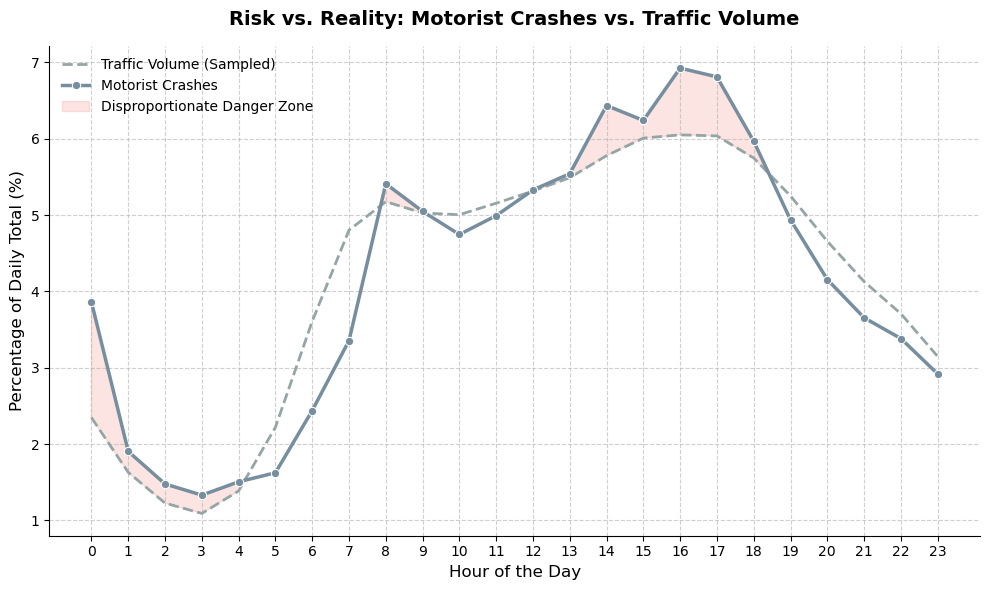

In [24]:
# ==========================================
# PLOT 5: NORMALIZING BY TRAFFIC VOLUME
# ==========================================

# Process traffic volume data by grouping by hour and calculating the percentage of daily traffic
hourly_volume = COUNT.groupby('HH')['Vol'].sum().reset_index()
total_vol = hourly_volume['Vol'].sum()
hourly_volume['Volume_Percentage'] = (hourly_volume['Vol'] / total_vol) * 100

# Filter for Motorists since automated traffic counts primarily capture motor vehicles
motorist_crashes = unique_crashes[unique_crashes['USER_CATEGORY'] == 'Motorist']

# Calculate the percentage of motorist crashes per hour
hourly_motorist = motorist_crashes.groupby('HOUR').size().reset_index(name='Crash_Count')
total_motorist_crashes = hourly_motorist['Crash_Count'].sum()
hourly_motorist['Crash_Percentage'] = (hourly_motorist['Crash_Count'] / total_motorist_crashes) * 100

# Merge collision data with traffic data on the hour column
normalized_hourly = hourly_motorist.merge(hourly_volume, left_on='HOUR', right_on='HH', how='inner')

plt.figure(figsize=(10, 6))

# Plot the baseline traffic volume expectation
sns.lineplot(
    data=normalized_hourly, 
    x='HOUR', 
    y='Volume_Percentage', 
    label='Traffic Volume (Sampled)', 
    color='#95a5a6', # Clean grey for baseline
    linestyle='--', 
    linewidth=2
)

# Plot the actual motorist crashes using the established category color
sns.lineplot(
    data=normalized_hourly, 
    x='HOUR', 
    y='Crash_Percentage', 
    label='Motorist Crashes', 
    color=category_colors['Motorist'], # Re-using the exact blue from earlier plots!
    linewidth=2.5, 
    marker='o'
)

plt.title('Risk vs. Reality: Motorist Crashes vs. Traffic Volume', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Percentage of Daily Total (%)', fontsize=12)
plt.xticks(range(0, 24))

# Highlight danger zones where the crash percentage exceeds the traffic volume percentage
plt.fill_between(
    normalized_hourly['HOUR'], 
    normalized_hourly['Volume_Percentage'], 
    normalized_hourly['Crash_Percentage'], 
    where=(normalized_hourly['Crash_Percentage'] > normalized_hourly['Volume_Percentage']), 
    interpolate=True, 
    color='#e74c3c', # Red warning color
    alpha=0.15, 
    label='Disproportionate Danger Zone'
)

# Format aesthetics to match the rest of the notebook
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()

plt.show()

### Demographics

Gender Breakdown Across User Categories:
PERSON_SEX     % Female  % Male
USER_CATEGORY                  
Cyclist            13.7    86.3
Motorist           32.9    67.1
Pedestrian         50.7    49.3
----------------------------------------


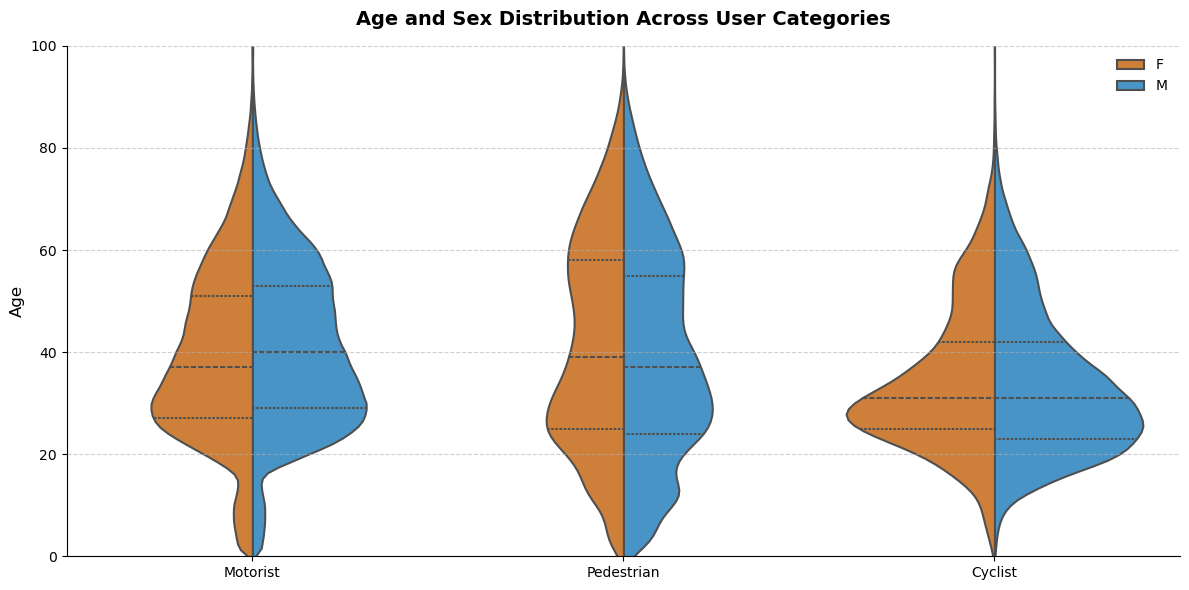

In [25]:
# ==========================================
# DEMOGRAPHICS (Age and Sex Violin Plot)
# ==========================================

# Filter out missing demographics to ensure clean visualizations
demo_df = PERSONS_CLEAN.dropna(subset=['PERSON_AGE', 'PERSON_SEX']).copy()

# Ensure only Male (M) and Female (F) are included to allow the split violin plot to work cleanly
demo_df = demo_df[demo_df['PERSON_SEX'].isin(['M', 'F'])]

# Print quick demographic statistics to support the markdown narrative
print("Gender Breakdown Across User Categories:")
gender_stats = demo_df.groupby(['USER_CATEGORY', 'PERSON_SEX']).size().unstack()
gender_stats['% Female'] = (gender_stats['F'] / (gender_stats['F'] + gender_stats['M'])) * 100
gender_stats['% Male'] = (gender_stats['M'] / (gender_stats['F'] + gender_stats['M'])) * 100
print(gender_stats[['% Female', '% Male']].round(1))
print("-" * 40)

plt.figure(figsize=(12, 6))

# Define distinct, professional colors for gender
gender_colors = {'M': '#3498db', 'F': '#e67e22'}

# Create a split violin plot to compare distributions side-by-side
sns.violinplot(
    data=demo_df, 
    x='USER_CATEGORY', 
    y='PERSON_AGE', 
    hue='PERSON_SEX', 
    split=True, 
    inner="quart", 
    palette=gender_colors,
    linewidth=1.5
)

plt.title('Age and Sex Distribution Across User Categories', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('', fontsize=12) # Left blank as categories are self-explanatory
plt.ylabel('Age', fontsize=12)

# Focus the y-axis on realistic human ages to remove empty visual space
plt.ylim(0, 100) 

# Format aesthetics 
plt.legend(title='', loc='upper right', frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()

plt.show()

### Fatality

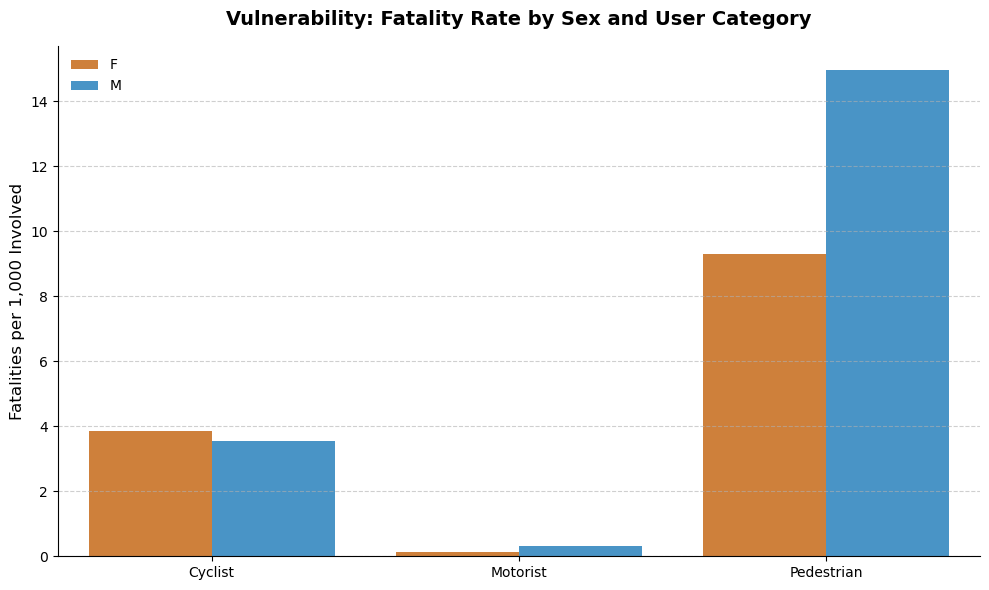

C:\Users\frida\AppData\Local\Temp\ipykernel_41864\802377006.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_fatality = demo_df.groupby(['USER_CATEGORY', 'AGE_GROUP'])['IS_FATAL'].mean().reset_index()


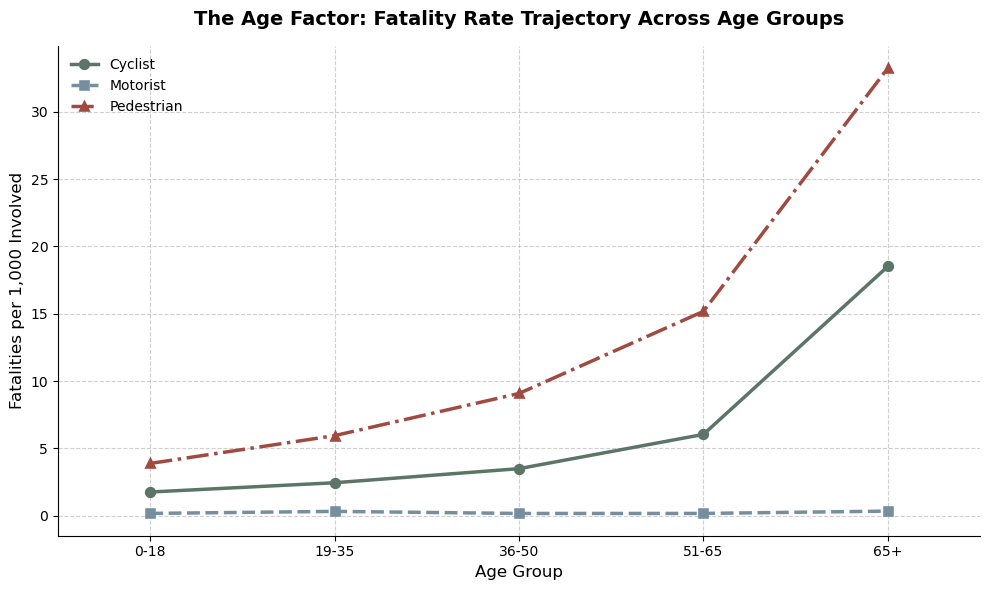

In [26]:
# ==========================================
# FATALITY RATES BY DEMOGRAPHICS
# ==========================================

# Create a clear binary flag for fatal injuries to ensure accurate calculations
demo_df['IS_FATAL'] = demo_df['PERSON_INJURY'] == 'Killed'

# Bin the ages into logical groups for trend analysis
age_bins = [0, 18, 35, 50, 65, 110]
age_labels = ['0-18', '19-35', '36-50', '51-65', '65+']
demo_df['AGE_GROUP'] = pd.cut(demo_df['PERSON_AGE'], bins=age_bins, labels=age_labels, right=False)


# ---------------------------------------------------------
# Plot A: Fatality Rate by Sex and User Category
# ---------------------------------------------------------

# Calculate the mean (percentage), then multiply by 1000 for a "per 1,000" rate
sex_fatality = demo_df.groupby(['USER_CATEGORY', 'PERSON_SEX'])['IS_FATAL'].mean().reset_index()
sex_fatality['Fatality_Rate_Per_1000'] = sex_fatality['IS_FATAL'] * 1000

plt.figure(figsize=(10, 6))

sns.barplot(
    data=sex_fatality, 
    x='USER_CATEGORY', 
    y='Fatality_Rate_Per_1000', 
    hue='PERSON_SEX', 
    palette=gender_colors # Re-using the established Blue/Orange palette
)

plt.title('Vulnerability: Fatality Rate by Sex and User Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('', fontsize=12) # Left blank as categories are self-explanatory
plt.ylabel('Fatalities per 1,000 Involved', fontsize=12)

# Clean up aesthetics
plt.legend(title='', frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# Plot B: Fatality Rate by Age Group and User Category
# ---------------------------------------------------------

# Calculate the fatality rate per 1,000 for each age group
age_fatality = demo_df.groupby(['USER_CATEGORY', 'AGE_GROUP'])['IS_FATAL'].mean().reset_index()
age_fatality['Fatality_Rate_Per_1000'] = age_fatality['IS_FATAL'] * 1000

plt.figure(figsize=(10, 6))

# A pointplot is highly effective here to show the rising trajectory of risk as age increases
sns.pointplot(
    data=age_fatality, 
    x='AGE_GROUP', 
    y='Fatality_Rate_Per_1000', 
    hue='USER_CATEGORY', 
    palette=category_colors,
    markers=['o', 's', '^'], 
    linestyles=['-', '--', '-.'],
    linewidth=2.5
)

plt.title('The Age Factor: Fatality Rate Trajectory Across Age Groups', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Fatalities per 1,000 Involved', fontsize=12)

# Clean up aesthetics
plt.legend(title='', frameon=False)
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()

plt.show()

### Vehicle Types

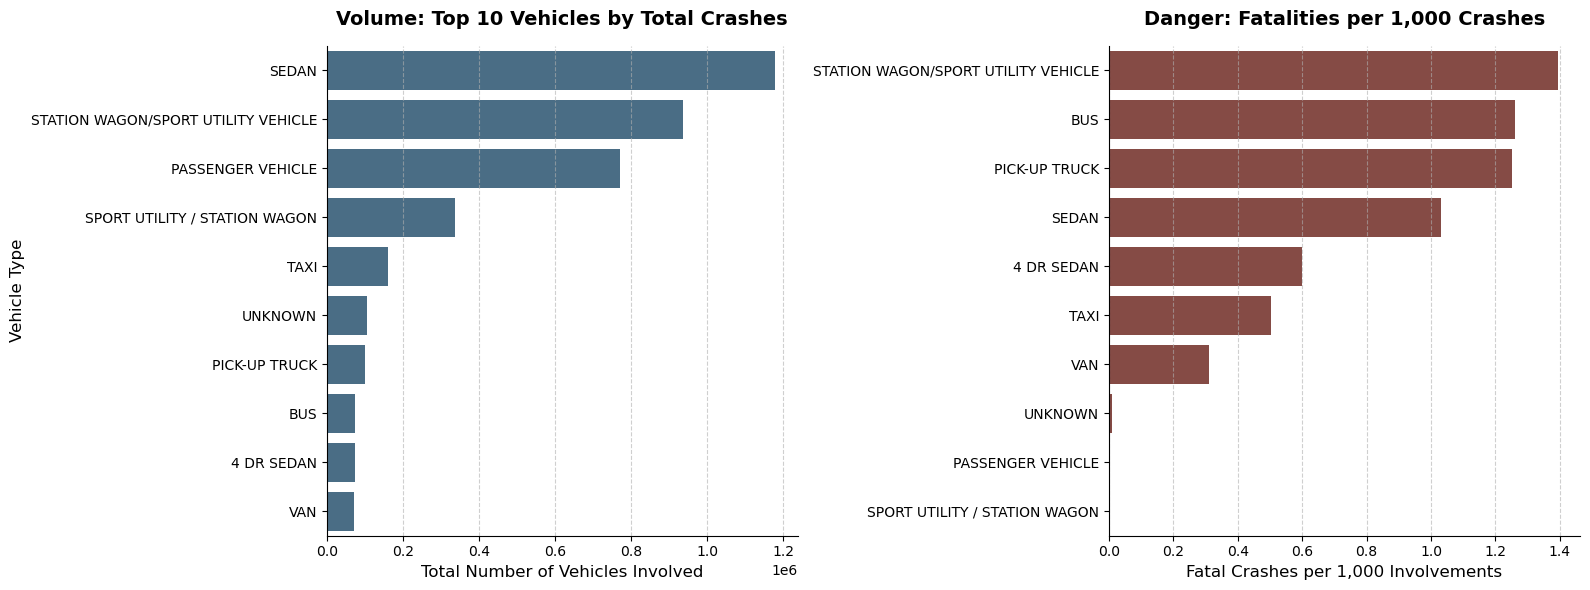

In [27]:
import gc

# ==========================================
# PLOT 9: VEHICLE TYPE INVOLVEMENT (MEMORY SAFE CHUNKING)
# ==========================================

# Create a fast-lookup set of fatal collision IDs to optimize memory during processing
fatal_collisions_set = set(demo_df[demo_df['IS_FATAL']]['COLLISION_ID'].unique())

# Initialize empty dictionaries to hold running tallies
vehicle_totals = {}
vehicle_fatals = {}

# Process the massive VEHICLES dataframe in manageable chunks to prevent memory overload
chunk_size = 500000 
for start_row in range(0, len(VEHICLES), chunk_size):
    
    # Slice a small chunk and extract only the necessary columns
    chunk = VEHICLES.iloc[start_row:start_row + chunk_size][['COLLISION_ID', 'VEHICLE_TYPE']].copy()
    
    # Standardize vehicle types for the current chunk
    chunk['VEHICLE_TYPE_CLEAN'] = chunk['VEHICLE_TYPE'].astype(str).str.upper().str.strip()
    
    # Flag fatalities in this chunk using the fast-lookup set
    chunk['INVOLVED_IN_FATALITY'] = chunk['COLLISION_ID'].isin(fatal_collisions_set)
    
    # Tally up the total involvement volume
    vol_counts = chunk['VEHICLE_TYPE_CLEAN'].value_counts().to_dict()
    for v_type, count in vol_counts.items():
        vehicle_totals[v_type] = vehicle_totals.get(v_type, 0) + count
        
    # Tally up the fatal crashes
    fatal_counts = chunk[chunk['INVOLVED_IN_FATALITY']]['VEHICLE_TYPE_CLEAN'].value_counts().to_dict()
    for v_type, count in fatal_counts.items():
        vehicle_fatals[v_type] = vehicle_fatals.get(v_type, 0) + count
        
    # Manually delete the chunk and force Python's Garbage Collector to free memory
    del chunk
    gc.collect()

# Convert dictionaries back into a structured dataframe
veh_stats = pd.DataFrame({
    'Total_Involvement': pd.Series(vehicle_totals),
    'Fatal_Crashes': pd.Series(vehicle_fatals)
}).fillna(0)

# Calculate the fatality rate per 1,000 involvements and sort
veh_stats['Fatality_Rate_Per_1000'] = (veh_stats['Fatal_Crashes'] / veh_stats['Total_Involvement']) * 1000
veh_stats = veh_stats.sort_values('Total_Involvement', ascending=False)

# Extract the Top 10 for visualization (dropping 'NAN' if missing values were captured as strings)
if 'NAN' in veh_stats.index:
    veh_stats = veh_stats.drop('NAN')
    
top_10_veh_stats = veh_stats.head(10).reset_index().rename(columns={'index': 'VEHICLE_TYPE_CLEAN'})


# ==========================================
# --- PLOTTING ---
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Total Volume
sns.barplot(
    data=top_10_veh_stats, 
    x='Total_Involvement', 
    y='VEHICLE_TYPE_CLEAN', 
    ax=axes[0], 
    color="#406f8f"
)

axes[0].set_title('Volume: Top 10 Vehicles by Total Crashes', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Total Number of Vehicles Involved', fontsize=12)
axes[0].set_ylabel('Vehicle Type', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# Plot B: Fatality Rate
veh_stats_danger = top_10_veh_stats.sort_values('Fatality_Rate_Per_1000', ascending=False)

sns.barplot(
    data=veh_stats_danger, 
    x='Fatality_Rate_Per_1000', 
    y='VEHICLE_TYPE_CLEAN', 
    ax=axes[1], 
    color="#90423a"
)

axes[1].set_title('Danger: Fatalities per 1,000 Crashes', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Fatal Crashes per 1,000 Involvements', fontsize=12)
axes[1].set_ylabel('') 
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

# clean layout
sns.despine()
plt.tight_layout()

plt.show()

## Machine Learning



DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is used to identify geographic crash hotspots across NYC. Unlike K-means, DBSCAN does not require a predefined number of clusters and can handle clusters of arbitrary shape. Points that do not belong to any cluster are treated as noise and ignored, ensuring that only genuine high-density zones are flagged as hotspots. The eps parameter defines the neighborhood radius and min_samples sets the minimum number of crashes required to form a cluster.

The clustering results are visualised as a bubble map, where each bubble represents a crash hotspot identified by DBSCAN. Bubble size reflects the total number of crashes in the cluster, while colour indicates the fatality rate — the darker the bubble, the deadlier the hotspot. This makes it possible to distinguish between high-volume areas and genuinely dangerous ones, as the two do not always overlap.
Beyond location and fatality rate, each cluster is enriched with a set of extracted features: peak hour, year-over-year trend, top contributing factor, median age of those involved, and the most crash-prone intersection within the cluster. These features are surfaced interactively when hovering over a bubble, allowing the reader to explore the data behind each hotspot rather than just its location.

DBSCAN has shown us where crashes concentrate. However, to truly get an understanding of why some crashes turn fatal and others don't, we turn also to a supervised machine learning approach: a Random Forest classifier trained separately for each persona. The model is framed as a binary classification problem: given that a crash has already occurred, which features then predict whether it turns fatal. 

Random Forest is well-suited to this problem as it handles a mix of numerical and categorical features without requiring scaling or distributional assumptions. The class_weight='balanced' parameter addresses the heavy class imbalance, preventing the model from defaulting to predicting non-fatal in every case.
Also, in our case the goal is NOT prediction but interpretation. Random Forest produces feature importances that quantify the relative contribution of each variable. This allows us to identify which factors most strongly drive fatality rather than simply describing patterns in the data.

The feature selection spans four categories: time (hour of day, day of week, month), place (borough), crash-level characteristics (contributing factor, vehicle types for both vehicles involved), and person-level attributes (age, sex, safety equipment, ejection status). For the Pedestrian model, two additional features are included: pedestrian location (crosswalk vs. mid-block) and pedestrian action at the time of the crash.

Evaluation is based on ROC-AUC rather than accuracy, as the latter is misleading for heavily imbalanced datasets. A ROC-AUC of 0.5 is equivalent to random guessing, while 1.0 represents a perfect classifier.
Missing values in person-level fields such as SAFETY_EQUIPMENT are retained as a separate category rather than removed, preserving as many records as possible for training.

The ROC curve is included as a validation step to confirm that the models perform meaningfully before interpreting their outputs. Rather than relying solely on the AUC score, plotting the full curve allows us to visually inspect model performance across all classification thresholds. All three models significantly outperform random guessing, giving us confidence that the feature importances derived from each classifier reflect genuine patterns in the data rather than noise.

The feature importance plots identify which variables most strongly predict fatality. Afterwards, more basic charts were genreated to translate these findings into concrete numbers, quantifying the effect of each key factor and breaking it down across the three personas. This showed us not just which variables matter, but by how much and for whom.

Also, not all of these charts appear directly on the website. The breakdown plots serve primarily as an analytical layer. This is a way of interrogating the model's outputs and verifying that the feature importances reflect interpretable, real-world patterns rather than statistical artefacts. By examining each factor individually across all three personas, we can be confident that the findings presented on the website are grounded in a thorough underlying analysis. The selected visualizations on the site represent the most accessible and narratively compelling results from this broader work.


In [28]:
#import necessary libraries
import pandas as pd 
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

In [29]:
# Import the datasets from the csv files to use for the machine learning part of the project
crashes = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes_20260407.csv", low_memory=False)      
persons = pd.read_csv("Motor_Vehicle_Collisions_-_Person_20260428.csv", low_memory=False)   
vehicles = pd.read_csv("Motor_Vehicle_Collisions_-_Vehicles_20260428.csv", low_memory=False)

### **DBSCAN**

In [30]:
# Check the number of crashes with missing or zero coordinates
total = len(crashes)
missing_lat = crashes["LATITUDE"].isna().sum()
missing_lon = crashes["LONGITUDE"].isna().sum()
missing_both = crashes[crashes["LATITUDE"].isna() & crashes["LONGITUDE"].isna()].shape[0]
zero_coords = crashes[(crashes["LATITUDE"] == 0) | (crashes["LONGITUDE"] == 0)].shape[0]

print(f"Total crashes:              {total:,}")
print(f"Missing LATITUDE:           {missing_lat:,} ({missing_lat/total*100:.1f}%)")
print(f"Missing LONGITUDE:          {missing_lon:,} ({missing_lon/total*100:.1f}%)")
print(f"Missing both:               {missing_both:,} ({missing_both/total*100:.1f}%)")
print(f"Zero coordinates (bad):     {zero_coords:,} ({zero_coords/total*100:.1f}%)")
print(f"\nUsable for spatial ML:      {total - missing_both - zero_coords:,} ({(total - missing_both - zero_coords)/total*100:.1f}%)")

Total crashes:              2,253,192
Missing LATITUDE:           240,676 (10.7%)
Missing LONGITUDE:          240,676 (10.7%)
Missing both:               240,676 (10.7%)
Zero coordinates (bad):     0 (0.0%)

Usable for spatial ML:      2,012,516 (89.3%)


In [31]:
# Looking at the contributing factors to crashes and how many of them are missing or unspecified
factor_col = "CONTRIBUTING FACTOR VEHICLE 1"
all_factors = crashes[factor_col].dropna()
print(f"Unique contributing factors: {all_factors.nunique()}")
print(f"Missing/Unspecified: {crashes[factor_col].isna().sum():,} NaN + {(crashes[factor_col] == 'Unspecified').sum():,} 'Unspecified'")
print(f"\nTop 5 values:")
print(crashes[factor_col].value_counts().head(5))

Unique contributing factors: 61
Missing/Unspecified: 8,152 NaN + 752,335 'Unspecified'

Top 5 values:
CONTRIBUTING FACTOR VEHICLE 1
Unspecified                       752335
Driver Inattention/Distraction    458307
Failure to Yield Right-of-Way     135071
Following Too Closely             120848
Backing Unsafely                   82129
Name: count, dtype: int64


In [32]:
# Checking how many crashes have associated person records and what types of persons are involved
crashes_with_persons = persons["COLLISION_ID"].nunique()
crashes_total = crashes["COLLISION_ID"].nunique()
crashes_without_persons = crashes_total - crashes_with_persons

print(f"Total unique crashes:                {crashes_total:,}")
print(f"Crashes with at least one person record: {crashes_with_persons:,} ({crashes_with_persons/crashes_total*100:.1f}%)")
print(f"Crashes with NO person record:       {crashes_without_persons:,} ({crashes_without_persons/crashes_total*100:.1f}%)")

print(f"\nPerson type breakdown in persons table:")
print(persons["PERSON_TYPE"].value_counts())

# Checking how many crashes involve cyclists and pedestrians based on the persons table
cyclist_crashes = persons[persons["PERSON_TYPE"] == "Bicyclist"]["COLLISION_ID"].nunique()
ped_crashes = persons[persons["PERSON_TYPE"] == "Pedestrian"]["COLLISION_ID"].nunique()
print(f"\nCrashes involving a cyclist:    {cyclist_crashes:,} ({cyclist_crashes/crashes_total*100:.1f}%)")
print(f"Crashes involving a pedestrian: {ped_crashes:,} ({ped_crashes/crashes_total*100:.1f}%)")

Total unique crashes:                2,253,192
Crashes with at least one person record: 1,627,701 (72.2%)
Crashes with NO person record:       625,491 (27.8%)

Person type breakdown in persons table:
PERSON_TYPE
Occupant           5705877
Pedestrian          146845
Bicyclist            80215
Other Motorized      12728
Name: count, dtype: int64

Crashes involving a cyclist:    77,436 (3.4%)
Crashes involving a pedestrian: 140,209 (6.2%)


In [33]:
# Checking the distribution of crashes across boroughs and how many are missing borough information
total = len(crashes)
missing_borough = crashes["BOROUGH"].isna().sum()

print(f"Total crashes:          {total:,}")
print(f"Missing BOROUGH:        {missing_borough:,} ({missing_borough/total*100:.1f}%)")
print(f"\nBorough distribution:")
print(crashes["BOROUGH"].value_counts(dropna=False))

missing_both = crashes[crashes["BOROUGH"].isna() & crashes["LATITUDE"].isna()].shape[0]
print(f"\nMissing borough AND lat/lon: {missing_both:,} ({missing_both/total*100:.1f}%)")

Total crashes:          2,253,192
Missing BOROUGH:        687,462 (30.5%)

Borough distribution:
BOROUGH
NaN              687462
BROOKLYN         502714
QUEENS           419324
MANHATTAN        346028
BRONX            232117
STATEN ISLAND     65547
Name: count, dtype: int64

Missing borough AND lat/lon: 202,821 (9.0%)


In [34]:
# Define parameters for DBSCAN clustering
# Convert radius from meters to radians (Earth's radius = 6,371,000m)
EPS_BY_PERSONA = {
    "Cyclist":    200 / 6_371_000,
    "Pedestrian": 200 / 6_371_000,
    "Motorist":    75 / 6_371_000,
}
MIN_SAMPLES = 30  # minimum crashes within eps radius to form a hotspot zone

print("Persona-specific eps values (in meters):")
for p, e in EPS_BY_PERSONA.items():
    print(f"  {p}: {e * 6_371_000:.0f}m")

Persona-specific eps values (in meters):
  Cyclist: 200m
  Pedestrian: 200m
  Motorist: 75m


In [35]:
# Filter and run DBSCAN per persona
persona_data = {}

crashes_ml = crashes.copy()

# Standardise coordinates and coerce non-numeric values
crashes_ml["LATITUDE"]  = pd.to_numeric(crashes_ml["LATITUDE"].str.replace(',', '.', regex=False),  errors="coerce")
crashes_ml["LONGITUDE"] = pd.to_numeric(crashes_ml["LONGITUDE"].str.replace(',', '.', regex=False), errors="coerce")

# Filter to valid NYC bounding box
crashes_ml = crashes_ml[
    crashes_ml["LATITUDE"].between(40.4, 41.0) &
    crashes_ml["LONGITUDE"].between(-74.4, -73.5)
].copy()

# Extract year and hour
crashes_ml["year"] = pd.to_datetime(crashes_ml["CRASH DATE"], errors="coerce").dt.year
crashes_ml["hour"] = pd.to_datetime(crashes_ml["CRASH TIME"], format="%H:%M", errors="coerce").dt.hour

# Create an "intersection" column for spatial analysis, combining on and cross street names
crashes_ml["intersection"] = (
    crashes_ml["ON STREET NAME"].str.strip() + " & " + crashes_ml["CROSS STREET NAME"].str.strip()
).where(crashes_ml["ON STREET NAME"].notna() & crashes_ml["CROSS STREET NAME"].notna())

print(f"Valid NYC crashes: {len(crashes_ml):,}\n")

# Define persona-specific filters based on injury/fatality columns
PERSONA_FILTERS = {
    "Cyclist":    (crashes_ml["NUMBER OF CYCLIST INJURED"] > 0)    | (crashes_ml["NUMBER OF CYCLIST KILLED"] > 0),
    "Pedestrian": (crashes_ml["NUMBER OF PEDESTRIANS INJURED"] > 0) | (crashes_ml["NUMBER OF PEDESTRIANS KILLED"] > 0),
    "Motorist":   (crashes_ml["NUMBER OF MOTORIST INJURED"] > 0)   | (crashes_ml["NUMBER OF MOTORIST KILLED"] > 0),
}


# Run DBSCAN clustering for each persona and summarize results
for persona, mask in PERSONA_FILTERS.items():
    df = crashes_ml[mask].copy()

    coords = np.radians(df[["LATITUDE", "LONGITUDE"]].values)

    # Run DBSCAN for each persona using haversine distance on Earth's surface
    df["cluster"] = DBSCAN(
        eps=EPS_BY_PERSONA[persona],
        min_samples=MIN_SAMPLES,
        algorithm="ball_tree",
        metric="haversine"
    ).fit_predict(coords)

    persona_data[persona] = df

    n_clusters = len(df[df["cluster"] >= 0]["cluster"].unique())
    n_noise    = (df["cluster"] == -1).sum()
    print(f"{persona} (eps={int(EPS_BY_PERSONA[persona]*6_371_000)}m):")
    print(f"  crashes:  {len(df):,}")
    print(f"  clusters: {n_clusters}")
    print(f"  noise:    {n_noise:,} ({n_noise/len(df)*100:.1f}%)")
    print()

Valid NYC crashes: 2,005,124

Cyclist (eps=200m):
  crashes:  60,871
  clusters: 151
  noise:    19,713 (32.4%)

Pedestrian (eps=200m):
  crashes:  123,154
  clusters: 215
  noise:    15,993 (13.0%)

Motorist (eps=75m):
  crashes:  308,871
  clusters: 2174
  noise:    151,302 (49.0%)



In [36]:
# Characterize each cluster using crash-level and person-level features
persons_clean = persons[["COLLISION_ID","PERSON_TYPE","PERSON_AGE","PERSON_SEX"]].copy()
persons_clean["PERSON_AGE"] = pd.to_numeric(persons_clean["PERSON_AGE"], errors="coerce")
# Remove invalid ages
persons_clean = persons_clean[(persons_clean["PERSON_AGE"] > 0) & (persons_clean["PERSON_AGE"] < 100)]

PERSON_TYPE_MAP = {"Cyclist": "Bicyclist", "Pedestrian": "Pedestrian", "Motorist": "Occupant"}

INJURED_COL = {"Cyclist": "NUMBER OF CYCLIST INJURED",     "Pedestrian": "NUMBER OF PEDESTRIANS INJURED", "Motorist": "NUMBER OF MOTORIST INJURED"}
KILLED_COL  = {"Cyclist": "NUMBER OF CYCLIST KILLED",      "Pedestrian": "NUMBER OF PEDESTRIANS KILLED",  "Motorist": "NUMBER OF MOTORIST KILLED"}

def top_factors(s, n=3):
    f = s[s.notna() & (s != "Unspecified")]
    return " | ".join(f.value_counts().index[:n].tolist()) if len(f) > 0 else "Unknown"

cluster_stats = {}

for persona, df in persona_data.items():
    clustered = df[df["cluster"] != -1]  # exclude noise points

    # Aggregate crash-level statistics per cluster
    crash_stats = clustered.groupby("cluster").agg(
        n_crashes        = ("COLLISION_ID",                  "count"),
        lat_center       = ("LATITUDE",                      "mean"),
        lon_center       = ("LONGITUDE",                     "mean"),
        pct_injured      = (INJURED_COL[persona],            lambda x: round((x > 0).mean() * 100, 1)),
        pct_killed       = (KILLED_COL[persona],             lambda x: round((x > 0).mean() * 100, 2)),
        peak_hour        = ("hour",                          lambda x: x.value_counts().idxmax() if x.notna().any() else -1),
        top_borough      = ("BOROUGH",                       lambda x: x.value_counts().index[0] if x.notna().any() else "Unknown"),
        top_3_factors    = ("CONTRIBUTING FACTOR VEHICLE 1", top_factors),
        top_intersection = ("intersection",                  lambda x: x.dropna().value_counts().index[0] if x.dropna().any() else "Unknown"),
    ).sort_values("n_crashes", ascending=False).reset_index()

    # Calculate year-over-year trend per cluster
    year_pivot = clustered.groupby(["cluster", "year"]).size().unstack(fill_value=0)
    crash_stats["year_trend"] = crash_stats["cluster"].map(
        lambda c: year_pivot.loc[c].to_dict() if c in year_pivot.index else {}
    )

    # Merge person-level statistics (age, sex) per cluster
    pers = persons_clean[persons_clean["PERSON_TYPE"] == PERSON_TYPE_MAP[persona]]
    df_p = clustered[["COLLISION_ID", "cluster"]].merge(pers, on="COLLISION_ID", how="left")
    person_stats = df_p.groupby("cluster").agg(
        median_age = ("PERSON_AGE", "median"),
        pct_female = ("PERSON_SEX", lambda x: round((x == "F").sum() / x.notna().sum() * 100, 1) if x.notna().any() else None),
    ).reset_index()

    stats = crash_stats.merge(person_stats, on="cluster", how="left")
    cluster_stats[persona] = stats

In [37]:
# We use the cluster centers and fatality rates to create a bubble map of "danger zones" for each persona
# ── 1. STYLING ──────────────────────────────────────────────────────────────
SITE_BG     = "white"
SITE_ACCENT = "#9D5C58"
SITE_FONT   = "Inter, Helvetica Neue, Helvetica, Arial, sans-serif"
SITE_TEXT   = "#1a1a1a"

FATALITY_COLORSCALE = [
    [0.00, "#f5eeee"],
    [0.40, "#d4a09d"],
    [0.70, "#b87570"],
    [1.00, "#9D5C58"],
]

for persona in ["Cyclist", "Pedestrian", "Motorist"]:
    stats = cluster_stats[persona]
    df    = persona_data[persona]
    noise = df[df["cluster"] == -1]

    stats_bubbles = stats[stats["pct_killed"] > 0].copy()

    # ── 2. FEATURE ENGINEERING ──────────────────────────────────────────────
    stats_bubbles["peak_hour_fmt"] = stats_bubbles["peak_hour"].apply(
        lambda h: f"{int(h):02d}:00" if h >= 0 else "Unknown"
    )
    stats_bubbles["top_factor"] = stats_bubbles["top_3_factors"].apply(
        lambda x: x.split(" | ")[0] if isinstance(x, str) and x != "Unknown" else "Unknown"
    )
    stats_bubbles["median_age_fmt"] = stats_bubbles["median_age"].apply(
        lambda x: f"{int(x)} yrs" if pd.notna(x) else "N/A"
    )

    def trend_direction(year_dict):
        if not year_dict or len(year_dict) < 3:
            return "→ stable"
        years = sorted([y for y in year_dict.keys() if y <= 2025 and y != 2020])
        if len(years) < 3:
            return "→ stable"
        counts = [year_dict[y] for y in years]
        slope = np.polyfit(years, counts, 1)[0]
        if slope > 2:
            return "↗ getting worse"
        elif slope < -2:
            return "↘ getting better"
        else:
            return "→ stable"

    stats_bubbles["trend"] = stats_bubbles["year_trend"].apply(trend_direction)

    cmax        = stats_bubbles["pct_killed"].quantile(0.90)
    log_size    = np.log1p(stats_bubbles["n_crashes"])
    size_scaled = 8 + (log_size - log_size.min()) / (log_size.max() - log_size.min() + 1e-9) * 37

    # ── 3. PLOTTING ──────────────────────────────────────────────────────────
    fig = go.Figure()

    noise_sample = noise.sample(n=min(5000, len(noise)), random_state=42)
    fig.add_trace(go.Scattermap(
        lat=noise_sample["LATITUDE"], lon=noise_sample["LONGITUDE"],
        mode="markers",
        marker=dict(size=3, color="#c9c5be", opacity=0.35),
        name="Isolated crash",
        hoverinfo="skip",
    ))

    fig.add_trace(go.Scattermap(
        lat=stats_bubbles["lat_center"], lon=stats_bubbles["lon_center"],
        mode="markers",
        marker=dict(
            size=size_scaled,
            color=stats_bubbles["pct_killed"],
            colorscale=FATALITY_COLORSCALE,
            cmin=0, cmax=cmax,
            colorbar=dict(
                title=dict(text="Fatality rate", font=dict(family=SITE_FONT, size=12, color=SITE_TEXT)),
                tickfont=dict(family=SITE_FONT, size=11, color=SITE_TEXT),
                thickness=10,
                len=0.45,
                bgcolor="white",
                borderwidth=0,
            ),
            opacity=0.85,
        ),
        text=stats_bubbles["top_intersection"],
        customdata=np.stack([
            stats_bubbles["n_crashes"],
            stats_bubbles["pct_killed"],
            stats_bubbles["peak_hour_fmt"],
            stats_bubbles["top_borough"],
            stats_bubbles["top_factor"],
            stats_bubbles["median_age_fmt"],
            stats_bubbles["trend"],
        ], axis=-1),
        hovertemplate=(
            "<b>%{text}</b><br><br>"
            "Crashes: <b>%{customdata[0]:,}</b><br>"
            "Fatality rate: <b>%{customdata[1]:.2f}%</b><br>"
            "Trend: %{customdata[6]}<br>"
            "Peak hour: %{customdata[2]}<br>"
            "Top cause: %{customdata[4]}<br>"
            "Median age: %{customdata[5]}<br>"
            "Borough: %{customdata[3]}<extra></extra>"
        ),
        name="Danger zone",
    ))

    fig.update_layout(
        font=dict(family=SITE_FONT, color=SITE_TEXT, size=13),
        map=dict(
            style="carto-positron",
            center=dict(lat=40.71, lon=-74.00),
            zoom=10,
        ),
        paper_bgcolor=SITE_BG,
        legend=dict(
            orientation="h", y=-0.04,
            font=dict(family=SITE_FONT, size=11, color=SITE_TEXT),
            bgcolor="white",
        ),
        margin=dict(l=40, r=40, t=50, b=40),
        height=650,
    )

    fig.show()

### **Random Forrest Classifier**

In [38]:
# Map persona names to person type labels used in the persons table
PERSONA_TYPE_MAP = {"Cyclist": "Bicyclist", "Pedestrian": "Pedestrian", "Motorist": "Occupant"}

# Numerical features passed directly to the model
NUM_FEATURES = ["hour", "day_of_week", "month", "PERSON_AGE"]

# Categorical features — encoded as integers before training
CAT_FEATURES = [
    "BOROUGH",
    "CONTRIBUTING FACTOR VEHICLE 1",
    "VEHICLE TYPE CODE 1",
    "VEHICLE TYPE CODE 2",
    "PERSON_SEX",
    "SAFETY_EQUIPMENT",
    "EJECTION",
    "PED_LOCATION",
    "PED_ACTION",
]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

rf_results  = {}   # stores model + importances per persona
rf_age_data = {}   # stores fatality-by-age-group per persona

# Extract day of week and month from crash date
crashes_rf = crashes_ml.copy()
crashes_rf["day_of_week"] = pd.to_datetime(crashes_rf["CRASH DATE"], errors="coerce").dt.dayofweek
crashes_rf["month"]       = pd.to_datetime(crashes_rf["CRASH DATE"], errors="coerce").dt.month

for persona in ["Cyclist", "Pedestrian", "Motorist"]:
    ptype = PERSONA_TYPE_MAP[persona]

    # Filter persons table to relevant persona and clean age values
    pers = persons[persons["PERSON_TYPE"] == ptype][
        ["COLLISION_ID", "PERSON_AGE", "PERSON_SEX", "PERSON_INJURY",
         "SAFETY_EQUIPMENT", "EJECTION", "PED_LOCATION", "PED_ACTION"]
    ].copy()
    pers["PERSON_AGE"] = pd.to_numeric(pers["PERSON_AGE"], errors="coerce")
    pers = pers[(pers["PERSON_AGE"] > 0) & (pers["PERSON_AGE"] < 100)]

    # Merge crash and person data on collision ID
    df_rf = crashes_rf.merge(pers, on="COLLISION_ID", how="inner")

    # Define binary target: 1 if person was killed, 0 otherwise
    df_rf["fatal"] = (df_rf["PERSON_INJURY"] == "Killed").astype(int)

    df_rf = df_rf[ALL_FEATURES + ["fatal"]].copy()
    df_rf = df_rf.dropna(subset=NUM_FEATURES + ["fatal"])

    # Fill missing categorical values with "Unknown" rather than dropping rows
    for col in CAT_FEATURES:
        df_rf[col] = df_rf[col].fillna("Unknown").astype(str)

    # Label encode categorical features
    encoders = {}
    for col in CAT_FEATURES:
        le = LabelEncoder()
        df_rf[col] = le.fit_transform(df_rf[col])
        encoders[col] = le

    X = df_rf[ALL_FEATURES].values
    y = df_rf["fatal"].values

    # Stratified train/test split to preserve fatal/non-fatal ratio
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Train Random Forest with balanced class weights to handle imbalance
    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    clf.fit(X_tr, y_tr)

    auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])
    importances = pd.Series(clf.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)

    rf_results[persona] = {
        "clf": clf, "auc": auc, "importances": importances, "encoders": encoders,
        "y_te": y_te, "y_proba": clf.predict_proba(X_te)[:, 1],
    }
    importances.to_csv(f"rf_importances_{persona.lower()}.csv", header=True)

    # Calculate fatality rate per age group for visualisation
    df_rf["age_group"] = pd.cut(
        df_rf["PERSON_AGE"],
        bins=[0, 18, 30, 45, 60, 75, 100],
        labels=["<18", "18-30", "31-45", "46-60", "61-75", "75+"],
    )
    rf_age_data[persona] = df_rf.groupby("age_group", observed=True)["fatal"].mean() * 100

In [39]:
# Persona colours matching the website design
COLORS = {
    'Cyclist':    '#5c85a4',
    'Pedestrian': '#9D5C58',
    'Motorist':   '#c4a258',
}

# Shared font and colour settings for all plots
SITE_FONT  = "Inter, Helvetica Neue, Helvetica, Arial, sans-serif"
SITE_TEXT  = "#1a1a1a"
SITE_PAPER = "white"
_BGCOLOR   = "white"
_GRIDCOLOR = "#e8e8e8"
_FONT_AXIS  = 12
_FONT_TITLE = 16

# Human-readable labels for feature importance plots
FEATURE_LABELS = {
    "PERSON_AGE":                      "Age",
    "hour":                            "Hour of day",
    "VEHICLE TYPE CODE 1":             "Vehicle type (primary)",
    "VEHICLE TYPE CODE 2":             "Vehicle type (other)",
    "BOROUGH":                         "Borough",
    "PED_ACTION":                      "Pedestrian action",
    "CONTRIBUTING FACTOR VEHICLE 1":   "Contributing factor",
    "month":                           "Month",
    "PED_LOCATION":                    "Pedestrian location",
    "day_of_week":                     "Day of week",
    "PERSON_SEX":                      "Sex",
    "EJECTION":                        "Ejection status",
    "SAFETY_EQUIPMENT":                "Safety equipment",
}

# Standardise raw vehicle type strings to consistent categories
VEHICLE_TYPE_MAP = {
    "Sedan":                               "Sedan",
    "PASSENGER VEHICLE":                   "Sedan",
    "4 dr sedan":                          "Sedan",
    "2 dr sedan":                          "Sedan",
    "3-Door":                              "Sedan",
    "Station Wagon/Sport Utility Vehicle": "SUV / Station Wagon",
    "SPORT UTILITY / STATION WAGON":       "SUV / Station Wagon",
    "subn":                                "SUV / Station Wagon",
    "Taxi":                                "Taxi",
    "TAXI":                                "Taxi",
    "Pick-up Truck":                       "Pick-up Truck",
    "PICK-UP TRUCK":                       "Pick-up Truck",
    "PK":                                  "Pick-up Truck",
    "VAN":                                 "Van",
    "Van":                                 "Van",
    "van":                                 "Van",
    "Refrigerated Van":                    "Van",
    "Carry All":                           "Van",
    "Bus":                                 "Bus",
    "BUS":                                 "Bus",
    "School Bus":                          "Bus",
    "Bike":                                "Bicycle",
    "BICYCLE":                             "Bicycle",
    "Motorcycle":                          "Motorcycle",
    "MOTORCYCLE":                          "Motorcycle",
    "Motorbike":                           "Motorcycle",
    "Moped":                               "Moped / Scooter",
    "MOPED":                               "Moped / Scooter",
    "SCOOTER":                             "Moped / Scooter",
    "Motorscooter":                        "Moped / Scooter",
    "Box Truck":                           "Box Truck",
    "Tractor Truck Diesel":                "Tractor Truck",
    "Tractor Truck Gasoline":              "Tractor Truck",
    "Flat Bed":                            "Flatbed",
    "Flat Rack":                           "Flatbed",
    "Stake or Rack":                       "Flatbed",
    "Dump":                                "Dump Truck",
    "TRUCK":                               "Truck",
    "Beverage Truck":                      "Delivery Truck",
    "Chassis Cab":                         "Delivery Truck",
    "Tow Truck / Wrecker":                 "Tow Truck",
    "Garbage or Refuse":                   "Garbage Truck",
    "LARGE COM VEH(6 OR MORE TIRES)":      "Large Commercial Vehicle",
    "SMALL COM VEH(4 TIRES)":              "Small Commercial Vehicle",
    "LIVERY VEHICLE":                      "Livery Vehicle",
    "Ambulance":                           "Ambulance",
    "AMBULANCE":                           "Ambulance",
    "AMBUL":                               "Ambulance",
    "FIRE TRUCK":                          "Fire Truck",
    "Lift Boom":                           "Lift Boom",
    "Concrete Mixer":                      "Concrete Mixer",
    "Tanker":                              "Tanker",
    "Armored Truck":                       "Armored Truck",
    "E-Bike":                              "E-Bike",
    "E-Scooter":                           "E-Scooter",
    "LIMO":                                "Limousine",
    "Convertible":                         "Convertible",
    "UNKNOWN":                             "Unknown",
    "OTHER":                               "Other",
    "Standing S":                          "Other",
}

In [40]:
fig_roc = go.Figure()

# Diagonal baseline representing random guessing (AUC = 0.50)
fig_roc.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode="lines",
    line=dict(color="#aaaaaa", dash="dash", width=1),
    name="Random (AUC = 0.50)",
    showlegend=True,
))

# Plot ROC curve for each persona
for persona, color in COLORS.items():
    y_te    = rf_results[persona]["y_te"]
    y_proba = rf_results[persona]["y_proba"]
    auc_val = rf_results[persona]["auc"]

    fpr, tpr, _ = roc_curve(y_te, y_proba)

    fig_roc.add_trace(go.Scatter(
        x=fpr, y=tpr,
        mode="lines",
        name=f"{persona}  (AUC = {auc_val:.3f})",
        line=dict(color=color, width=2.5),
    ))

# All three models significantly outperform random guessing
# Higher AUC = better at distinguishing fatal from non-fatal crashes
fig_roc.update_layout(
    font=dict(family=SITE_FONT, color=SITE_TEXT, size=13),
    title=dict(
        text="<b>ROC curves for fatality prediction models</b>",
        font=dict(family=SITE_FONT, size=_FONT_TITLE, color=SITE_TEXT),
        x=0.5,
    ),
    xaxis=dict(
        title="False positive rate",
        range=[0, 1],
        gridcolor=_GRIDCOLOR,
        zeroline=False,
    ),
    yaxis=dict(
        title="True positive rate",
        range=[0, 1],
        gridcolor=_GRIDCOLOR,
        zeroline=False,
    ),
    plot_bgcolor=_BGCOLOR,
    paper_bgcolor=SITE_PAPER,
    legend=dict(
        x=0.55, y=0.08,
        font=dict(family=SITE_FONT, size=12, color=SITE_TEXT),
        bgcolor="rgba(255,255,255,0.7)",
        borderwidth=0,
    ),
    height=480,
    margin=dict(t=100, b=60, l=70, r=40),
)

fig_roc.show()

In [41]:
# Feaure importance plots showing which features were most 
# influential in predicting fatality for each persona's model
for persona in ['Cyclist', 'Pedestrian', 'Motorist']:
    imp = rf_results[persona]['importances'].copy()

    # Replace raw feature names with human-readable labels
    imp.index = [FEATURE_LABELS.get(f, f) for f in imp.index]

    fig = go.Figure(go.Bar(
        x=imp.values,
        y=imp.index,
        orientation='h',
        marker=dict(color=COLORS[persona], line_width=0),
        hovertemplate='<b>%{y}</b><br>Importance: %{x:.4f}<extra></extra>',
    ))

    fig.update_layout(
        font=dict(family=SITE_FONT, color=SITE_TEXT, size=13),
        title=dict(
            text=f"<b>Feature importances — {persona}</b>",
            font=dict(family=SITE_FONT, size=_FONT_TITLE, color=SITE_TEXT),
            x=0.5,
        ),
        xaxis=dict(
            title='Importance score',
            gridcolor=_GRIDCOLOR,
            zeroline=False,
            tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
        ),
        yaxis=dict(
            autorange='reversed',
            tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
        ),
        plot_bgcolor=_BGCOLOR,
        paper_bgcolor=SITE_PAPER,
        height=480,
        margin=dict(l=220, r=40, t=110, b=60),
    )

    fig.show()

In [42]:
# ── Data preparation for breakdown charts ────────────────────────────────────
persona_raw = {}

for persona in ["Cyclist", "Pedestrian", "Motorist"]:
    ptype = PERSONA_TYPE_MAP[persona]

    # Filter persons table to relevant persona and clean age values
    pers = persons[persons["PERSON_TYPE"] == ptype][
        ["COLLISION_ID", "PERSON_AGE", "PERSON_SEX", "PERSON_INJURY",
         "SAFETY_EQUIPMENT", "EJECTION", "PED_LOCATION", "PED_ACTION"]
    ].copy()
    pers["PERSON_AGE"] = pd.to_numeric(pers["PERSON_AGE"], errors="coerce")
    pers = pers[(pers["PERSON_AGE"] > 0) & (pers["PERSON_AGE"] < 100)]

    # Merge with crash data and define binary fatality target
    df = crashes_rf.merge(pers, on="COLLISION_ID", how="inner")
    df["fatal"] = (df["PERSON_INJURY"] == "Killed").astype(int)

    # Standardise categorical columns and fill missing values
    for col in ["SAFETY_EQUIPMENT", "EJECTION", "PED_LOCATION", "PED_ACTION",
                "VEHICLE TYPE CODE 1", "BOROUGH"]:
        df[col] = df[col].fillna("Unknown").astype(str).str.strip()

    persona_raw[persona] = df
    print(f"{persona}: {len(df):,} rows, {df['fatal'].sum()} fatal")

Cyclist: 72,552 rows, 250 fatal
Pedestrian: 130,596 rows, 1521 fatal
Motorist: 4,053,112 rows, 1196 fatal


In [43]:
# ── Ejection status vs fatality rate ─────────────────────────────────────────
COL_EJ        = "EJECTION"
MIN_COUNT_EJ  = 50          # exclude categories with fewer than 50 observations

for persona in ['Cyclist', 'Pedestrian', 'Motorist']:
    df = persona_raw[persona]

    # Calculate fatality rate per ejection category
    stats_ej = (
        df.groupby(COL_EJ)
        .agg(n=('fatal', 'count'), fatality_rate=('fatal', lambda x: x.mean() * 100))
        .reset_index()
    )
    # Filter out low-count categories and sort by fatality rate
    stats_ej = stats_ej[stats_ej['n'] >= MIN_COUNT_EJ].sort_values('fatality_rate', ascending=True)

    fig = go.Figure(go.Bar(
        x=stats_ej['fatality_rate'],
        y=stats_ej[COL_EJ],
        orientation='h',
        marker=dict(color=COLORS[persona], line_width=0),
        customdata=stats_ej['n'],
        hovertemplate='<b>%{y}</b><br>Fatality rate: %{x:.2f}%<br>n=%{customdata:,}<extra></extra>',
    ))

    fig.update_layout(
        font=dict(family=SITE_FONT, color=SITE_TEXT, size=13),
        title=dict(
            text=f'<b>Fatality rate by {FEATURE_LABELS[COL_EJ].lower()} — {persona}</b>',
            font=dict(family=SITE_FONT, size=_FONT_TITLE, color=SITE_TEXT),
            x=0.5,
        ),
        xaxis=dict(
            title='Fatality rate (%)',
            gridcolor=_GRIDCOLOR,
            zeroline=False,
            tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
        ),
        yaxis=dict(
            title=FEATURE_LABELS[COL_EJ],
            tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
        ),
        plot_bgcolor=_BGCOLOR,
        paper_bgcolor=SITE_PAPER,
        height=max(340, 120 + len(stats_ej) * 55),
        margin=dict(l=180, r=40, t=110, b=60),
    )

    fig.show()

In [44]:
# ── Fatality rate by hour of day ──────────────────────────────────────────────
MIN_N_HOUR = 30   # require at least 30 crashes per hour for a stable rate estimate

fig_hour = go.Figure()

for persona, color in COLORS.items():
    df = persona_raw[persona]

    # Calculate fatality rate per hour and filter low-count hours
    hour_stats = (
        df.groupby("hour")
        .agg(n=("fatal", "count"), fatality_rate=("fatal", lambda x: x.mean() * 100))
        .reset_index()
    )
    hour_stats = hour_stats[hour_stats["n"] >= MIN_N_HOUR]

    fig_hour.add_trace(go.Scatter(
        x=hour_stats["hour"],
        y=hour_stats["fatality_rate"],
        mode="lines+markers",
        name=persona,
        line=dict(color=color, width=2.5),
        marker=dict(size=6),
        hovertemplate="Hour %{x}:00<br>Fatality rate: %{y:.3f}%<extra>" + persona + "</extra>",
    ))

# Late-night crashes are disproportionately deadly despite lower volume
fig_hour.update_layout(
    font=dict(family=SITE_FONT, color=SITE_TEXT, size=13),
    title=dict(
        text="<b>Fatality rate by hour of day</b>",
        font=dict(family=SITE_FONT, size=_FONT_TITLE, color=SITE_TEXT),
        x=0.5,
    ),
    xaxis=dict(
        title="Hour of day",
        tickmode="linear",
        dtick=2,
        range=[-0.5, 23.5],
        gridcolor=_GRIDCOLOR,
        tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
    ),
    yaxis=dict(
        title="Fatality rate (%)",
        gridcolor=_GRIDCOLOR,
        zeroline=False,
        tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
    ),
    plot_bgcolor=_BGCOLOR,
    paper_bgcolor=SITE_PAPER,
    legend=dict(
        orientation="h", y=-0.2, x=0.5, xanchor="center",
        font=dict(family=SITE_FONT, size=12, color=SITE_TEXT),
    ),
    height=440,
    margin=dict(t=110, b=90, l=70, r=40),
)

fig_hour.show()

In [45]:
# ── Fatality rate by age group ────────────────────────────────────────────────
# Age is the #1 RF predictor for cyclists and pedestrians

fig_age = go.Figure()

for persona, age_fatal in rf_age_data.items():
    fig_age.add_trace(go.Scatter(
        x=age_fatal.index.astype(str),
        y=age_fatal.values.round(3),
        mode='lines+markers',
        name=persona,
        line=dict(color=COLORS[persona], width=2.5),
        marker=dict(size=8),
        hovertemplate='Age group: %{x}<br>Fatality rate: %{y:.3f}%<extra>' + persona + '</extra>',
    ))

fig_age.update_layout(
    font=dict(family=SITE_FONT, color=SITE_TEXT, size=13),
    title=dict(
        text='<b>Fatality rate by age group</b>',
        font=dict(family=SITE_FONT, size=_FONT_TITLE, color=SITE_TEXT),
        x=0.5,
    ),
    xaxis=dict(
        title='Age group',
        gridcolor=_GRIDCOLOR,
        tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
    ),
    yaxis=dict(
        title='Fatality rate (%)',
        gridcolor=_GRIDCOLOR,
        zeroline=False,
        tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
    ),
    plot_bgcolor=_BGCOLOR,
    paper_bgcolor=SITE_PAPER,
    legend=dict(
        orientation='h', y=-0.2, x=0.5, xanchor='center',
        font=dict(family=SITE_FONT, size=12, color=SITE_TEXT),
    ),
    height=440,
    margin=dict(t=110, b=90, l=70, r=40),
)

fig_age.show()

In [46]:
# ── Fatality rate by age group ─────────────────────────────────────────────────
# Granular age breakdown to support the age findings from the Random Forest model
bins   = [0, 10, 20, 30, 40, 50, 60, 70, 80, 100]
labels = ['0-10','11-20','21-30','31-40','41-50','51-60','61-70','71-80','81+']

PERSON_TYPE_MAP = {'Cyclist': 'Bicyclist', 'Pedestrian': 'Pedestrian', 'Motorist': 'Occupant'}

for persona, ptype in PERSON_TYPE_MAP.items():
    # Filter to relevant persona and clean age values
    p = persons[persons['PERSON_TYPE'] == ptype].copy()
    p['PERSON_AGE'] = pd.to_numeric(p['PERSON_AGE'], errors='coerce')
    p = p[(p['PERSON_AGE'] > 0) & (p['PERSON_AGE'] < 100)]

    # Define binary fatality target and assign age group
    p['fatal'] = (p['PERSON_INJURY'] == 'Killed').astype(int)
    p['age_group'] = pd.cut(p['PERSON_AGE'], bins=bins, labels=labels)

    # Calculate total crashes, fatalities and fatality rate per age group
    age_stats = p.groupby('age_group', observed=True).agg(
        total=('fatal', 'count'),
        killed=('fatal', 'sum')
    ).assign(fatality_rate=lambda x: (x['killed'] / x['total'] * 100).round(3))

    # Print summary with peak and lowest fatality age groups
    print(f'\n── {persona} ──')
    print(age_stats.to_string())
    peak = age_stats['fatality_rate'].idxmax()
    low  = age_stats['fatality_rate'].idxmin()
    print(f'  Peak:   {peak}  →  {age_stats.loc[peak, "fatality_rate"]:.3f}%')
    print(f'  Lowest: {low}  →  {age_stats.loc[low,  "fatality_rate"]:.3f}%')


── Cyclist ──
           total  killed  fatality_rate
age_group                              
0-10        1092       1          0.092
11-20      12470      21          0.168
21-30      25702      68          0.265
31-40      18496      50          0.270
41-50      10003      43          0.430
51-60       7046      45          0.639
61-70       3108      32          1.030
71-80        758      17          2.243
81+          117       5          4.274
  Peak:   81+  →  4.274%
  Lowest: 0-10  →  0.092%

── Pedestrian ──
           total  killed  fatality_rate
age_group                              
0-10        8765      60          0.685
11-20      17596      51          0.290
21-30      27172     159          0.585
31-40      22726     175          0.770
41-50      18649     200          1.072
51-60      19495     290          1.488
61-70      15052     334          2.219
71-80       7918     243          3.069
81+         3273     204          6.233
  Peak:   81+  →  6.233%
  Lowest: 1

In [47]:
# ── Fatality rate by vehicle type ─────────────────────────────────────────────
COL_VEH    = "VEHICLE TYPE CODE 1"
COL_CLEAN  = "vehicle_type_clean"
TOP_N_VEH  = 12    # limit to top 12 vehicle types by crash volume
MIN_N_VEH  = 50    # exclude vehicle types with fewer than 50 observations

# Subtitle differs by persona — cyclists/pedestrians are hit by a vehicle,
# motorists are travelling in one
SUBTITLE_VEH = {
    'Cyclist':    'hit by...',
    'Pedestrian': 'hit by...',
    'Motorist':   'travelling in...',
}

for persona in ['Cyclist', 'Pedestrian', 'Motorist']:
    df = persona_raw[persona].copy()

    # Standardise raw vehicle type strings using VEHICLE_TYPE_MAP
    df[COL_CLEAN] = df[COL_VEH].map(VEHICLE_TYPE_MAP).fillna(df[COL_VEH])

    # Filter to top N vehicle types by crash volume
    top_types = df[COL_CLEAN].value_counts().head(TOP_N_VEH).index
    sub = df[df[COL_CLEAN].isin(top_types)]

    # Calculate fatality rate per vehicle type and filter low-count categories
    stats_v = (
        sub.groupby(COL_CLEAN)
        .agg(n=('fatal', 'count'), fatality_rate=('fatal', lambda x: x.mean() * 100))
        .reset_index()
    )
    stats_v = stats_v[stats_v['n'] >= MIN_N_VEH].sort_values('fatality_rate', ascending=True)

    fig = go.Figure(go.Bar(
        x=stats_v['fatality_rate'],
        y=stats_v[COL_CLEAN],
        orientation='h',
        marker=dict(color=COLORS[persona], line_width=0),
        customdata=stats_v['n'],
        hovertemplate='<b>%{y}</b><br>Fatality rate: %{x:.2f}%<br>n=%{customdata:,}<extra></extra>',
    ))

    fig.update_layout(
        font=dict(family=SITE_FONT, color=SITE_TEXT, size=13),
        title=dict(
            text=f'<b>Fatality rate by {FEATURE_LABELS[COL_VEH].lower()} — {persona} {SUBTITLE_VEH[persona]}</b>',
            font=dict(family=SITE_FONT, size=_FONT_TITLE, color=SITE_TEXT),
            x=0.5,
        ),
        xaxis=dict(
            title='Fatality rate (%)',
            gridcolor=_GRIDCOLOR,
            zeroline=False,
            tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
        ),
        yaxis=dict(
            title=FEATURE_LABELS[COL_VEH],
            tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
        ),
        plot_bgcolor=_BGCOLOR,
        paper_bgcolor=SITE_PAPER,
        height=max(380, 120 + len(stats_v) * 45),
        margin=dict(l=260, r=40, t=110, b=60),
    )

    fig.show()

In [48]:
# ── Fatality rate by pedestrian action ───────────────────────────────────────
# Pedestrian-specific feature: what the pedestrian was doing at the time of the crash
COL_PED_ACT = "PED_ACTION"

df_ped = persona_raw['Pedestrian']

# Calculate fatality rate per pedestrian action, exclude low-count categories
stats_action = (
    df_ped.groupby(COL_PED_ACT)
    .agg(n=('fatal', 'count'), fatality_rate=('fatal', lambda x: x.mean() * 100))
    .reset_index()
)
stats_action = stats_action[stats_action['n'] >= 100].sort_values('fatality_rate', ascending=True)

fig_ped = go.Figure(go.Bar(
    x=stats_action['fatality_rate'],
    y=stats_action[COL_PED_ACT],
    orientation='h',
    marker=dict(color=COLORS['Pedestrian'], line_width=0),
    customdata=stats_action['n'],
    hovertemplate='<b>%{y}</b><br>Fatality rate: %{x:.2f}%<br>n=%{customdata:,}<extra></extra>',
))

# What a pedestrian was doing at the time of the crash has a significant effect
# on survival — crossing against the signal or mid-block carries the highest fatality rates
fig_ped.update_layout(
    font=dict(family=SITE_FONT, color=SITE_TEXT, size=13),
    title=dict(
        text='<b>Fatality rate by pedestrian action</b>',
        font=dict(family=SITE_FONT, size=_FONT_TITLE, color=SITE_TEXT),
        x=0.5,
    ),
    xaxis=dict(
        title='Fatality rate (%)',
        gridcolor=_GRIDCOLOR,
        zeroline=False,
        tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
    ),
    yaxis=dict(
        title=FEATURE_LABELS[COL_PED_ACT],
        tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
    ),
    plot_bgcolor=_BGCOLOR,
    paper_bgcolor=SITE_PAPER,
    height=max(380, 120 + len(stats_action) * 45),
    margin=dict(l=280, r=40, t=110, b=60),
)

fig_ped.show()

In [49]:
# ── Contributing factors: crash volume vs fatality rate ───────────────────────
# Side-by-side comparison reveals that the most common factors are not
# necessarily the most deadly ones
from plotly.subplots import make_subplots

COL_FAC   = "CONTRIBUTING FACTOR VEHICLE 1"
TOP_N_FAC = 15    # limit to top 15 factors by crash volume
MIN_N_FAC = 30    # exclude factors with fewer than 30 observations

for persona in ['Cyclist', 'Pedestrian', 'Motorist']:
    df = persona_raw[persona]

    # Remove uninformative factor values
    df_fac = df[~df[COL_FAC].isin(['Unspecified', 'Unknown', '1'])]
    top_factors_list = df_fac[COL_FAC].value_counts().head(TOP_N_FAC).index
    sub = df_fac[df_fac[COL_FAC].isin(top_factors_list)]

    # Calculate crash volume and fatality rate per contributing factor
    stats_fac = (
        sub.groupby(COL_FAC)
        .agg(n=('fatal', 'count'), fatality_rate=('fatal', lambda x: x.mean() * 100))
        .reset_index()
    )
    stats_fac = stats_fac[stats_fac['n'] >= MIN_N_FAC].sort_values('fatality_rate', ascending=True)

    # Two-panel plot: left = crash volume, right = fatality rate
    fig_fac = make_subplots(
        rows=1, cols=2,
        subplot_titles=['How common (crash volume)', 'How lethal (fatality rate)'],
        horizontal_spacing=0.18,
    )

    # Left panel: crash volume per factor
    fig_fac.add_trace(go.Bar(
        x=stats_fac['n'],
        y=stats_fac[COL_FAC],
        orientation='h',
        marker=dict(color=COLORS[persona], opacity=0.45, line_width=0),
        hovertemplate='<b>%{y}</b><br>Crashes: %{x:,}<extra></extra>',
        showlegend=False,
    ), row=1, col=1)

    # Right panel: fatality rate per factor
    fig_fac.add_trace(go.Bar(
        x=stats_fac['fatality_rate'],
        y=stats_fac[COL_FAC],
        orientation='h',
        marker=dict(color=COLORS[persona], line_width=0),
        customdata=stats_fac['n'],
        hovertemplate='<b>%{y}</b><br>Fatality rate: %{x:.2f}%<br>n=%{customdata:,}<extra></extra>',
        showlegend=False,
    ), row=1, col=2)

    fig_fac.update_xaxes(
        title_text='Number of crashes',
        gridcolor=_GRIDCOLOR, zeroline=False,
        tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
        row=1, col=1,
    )
    fig_fac.update_xaxes(
        title_text='Fatality rate (%)',
        gridcolor=_GRIDCOLOR, zeroline=False,
        tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
        row=1, col=2,
    )
    fig_fac.update_yaxes(
        title_text=FEATURE_LABELS[COL_FAC],
        tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
        row=1, col=1,
    )
    fig_fac.update_yaxes(showticklabels=False, row=1, col=2)

    fig_fac.update_layout(
        font=dict(family=SITE_FONT, color=SITE_TEXT, size=13),
        title=dict(
            text=f'<b>Contributing factors — {persona}</b>',
            font=dict(family=SITE_FONT, size=_FONT_TITLE, color=SITE_TEXT),
            x=0.5,
        ),
        plot_bgcolor=_BGCOLOR,
        paper_bgcolor=SITE_PAPER,
        height=max(460, 140 + len(stats_fac) * 40),
        margin=dict(l=230, r=40, t=120, b=60),
    )

    fig_fac.show()

In [50]:
# ── Fatality rate by safety equipment ─────────────────────────────────────────
# Safety equipment ranked low in feature importance — this plot investigates why
COL_SAFE       = "SAFETY_EQUIPMENT"
MIN_COUNT_SAFE = 100    # exclude categories with fewer than 100 observations

for persona in ['Cyclist', 'Pedestrian', 'Motorist']:
    df = persona_raw[persona]

    # Calculate fatality rate per safety equipment category
    stats_s = (
        df.groupby(COL_SAFE)
        .agg(n=('fatal', 'count'), fatality_rate=('fatal', lambda x: x.mean() * 100))
        .reset_index()
    )
    stats_s = stats_s[stats_s['n'] >= MIN_COUNT_SAFE].sort_values('fatality_rate', ascending=True)

    fig = go.Figure(go.Bar(
        x=stats_s['fatality_rate'],
        y=stats_s[COL_SAFE],
        orientation='h',
        marker=dict(color=COLORS[persona], line_width=0),
        customdata=stats_s['n'],
        hovertemplate='<b>%{y}</b><br>Fatality rate: %{x:.2f}%<br>n=%{customdata:,}<extra></extra>',
    ))

    fig.update_layout(
        font=dict(family=SITE_FONT, color=SITE_TEXT, size=13),
        title=dict(
            text=f'<b>Fatality rate by {FEATURE_LABELS[COL_SAFE].lower()} — {persona}</b>',
            font=dict(family=SITE_FONT, size=_FONT_TITLE, color=SITE_TEXT),
            x=0.5,
        ),
        xaxis=dict(
            title='Fatality rate (%)',
            gridcolor=_GRIDCOLOR,
            zeroline=False,
            tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
        ),
        yaxis=dict(
            title=FEATURE_LABELS[COL_SAFE],
            tickfont=dict(family=SITE_FONT, size=_FONT_AXIS, color=SITE_TEXT),
        ),
        plot_bgcolor=_BGCOLOR,
        paper_bgcolor=SITE_PAPER,
        height=max(380, 120 + len(stats_s) * 45),
        margin=dict(l=220, r=40, t=110, b=60),
    )

    fig.show()

# 4. Genre

This project uses a mix of Magazine Style and Slide Show. The overall structure follows the Magazine Style genre — scrollytelling embeds interactive visualizations within a narrative text flow, where the text provides context and the visualization provides evidence. Within each persona chapter, the experience follows a Slide Show structure, guiding the user. 


### Visual Narrative
**Visual Structuring:**
- *Establishing Shot*: The intro section — with the animated NYC map drawing itself in and the persona selection — functions as an establishing shot. It orients the user spatially (NYC) and narratively (three perspectives to choose from) before any data is shown.
- *Consistent Visual Platform*: Throughout the scrollytelling, the layout is fixed: sticky plot on the left and narrative text on the right. This gives the user a reliable spatial anchor so cognitive effort can go toward the content rather than the interface.
- *Progress Bar*: The progress dots at the bottom of the plot panel indicate how far the user is through the story, reducing disorientation in a long scroll-driven narrative.

**Highlighting:**
- *Close-Ups / Details on Demand*: Hovering over any bubble map cluster or bar chart reveals exact values — crash count, fatality rate, peak hour, contributing factor — functioning as a close-up on individual data points without cluttering the default view.
- *Feature Distinction*: Visual properties are used consistently throughout to separate what matters from what doesn't. On the bubble maps, size encodes crash volume and color encodes fatality rate such that a large pale bubble reads differently from a small dark one at a glance. The contributing factors chart uses opacity to distinguish primary from secondary information. The active scroll step gets a colored left border; inactive steps stay transparent. The progress dots use both size and color to mark where the reader is.
- *Motion*: The bouncing arrow on the intro screen, the animated NYC map, the fade transition between plots, and the floating character all use motion to guide attention and signal that the story is moving forward.
- *Zooming*: The interactive bubble maps support zooming — users can drill down into specific boroughs or intersections to inspect individual danger clusters at street level.

**Transition Guidance:**
- *Animated Transitions*: When scrolling triggers a new step, the iframe fades out and fades back in with the new plot. This prevents the jarring visual swap that would occur with a hard cut, helping the user understand that a new data view has loaded.
- *Object Continuity*: The sticky plot panel and floating character persist across all steps. The character's continuous presence — changing expression but not disappearing — maintains a sense of narrative continuity as the data changes around it.

### Narrative Structure
**Ordering:**
- *Linear*: Within each persona, the story follows a fixed sequence: temporal patterns → geography → predictive factors → contributing causes → conclusion. The user cannot reorder steps; each slide builds on the previous one, ensuring the narrative argument is legible.
- *User-Directed Path*: At the macro level, the user selects their own entry point — cyclist, pedestrian, or motorist. This choice personalizes the experience before the linear narrative begins.

**Interactivity:**
- *Hover Highlighting / Details on Demand*: All Plotly charts support hover interactions. The bubble maps reveal rich cluster-level statistics on hover — crash count, fatality rate, peak hour, top contributing factor, trend direction, and median age — exposing detail only when the user actively seeks it.
- *Navigation Buttons*: The "Change perspective" button and the restart button at the end allow the user to exit and re-enter the story from a different persona without reloading the page.
- *Explicit Instruction*: The "↗ Interactive" chip in every figure caption signals that the visualization can be explored. "Scroll to start the story" and the bouncing arrow explicitly tell the user what action to take next.
- *Stimulating Default Views*: The bubble maps use a log-scaled color scheme that draws the eye immediately to high-fatality clusters in dark red. The animated NYC map on the intro screen creates an engaging first impression before any interaction is required.

**Messaging:**
- *Captions / Headlines*: Every plot has a figure caption summarizing what is shown. Every step has a heading. The hook section presents a large numeric headline that establishes the scale of the problem before any analysis begins.
- *Introductory Text*: The hook section — with the big statistic and the framing text "Motor vehicle collisions are not accidents" — serves as introductory text establishing the stakes before the scrollytelling begins.
- *Summary / Synthesis*: "The Bigger Picture" section synthesizes the key finding across all three personas and connects it to policy implications — a final authorial statement that closes the narrative loop.
- *Multi-Messaging*: The thought bubble and the main body text address the same plot simultaneously from two registers — the character's emotional gut reaction and the analytical narrative text. This provides redundant messaging across two parallel channels, reinforcing key observations.

# 5. Visualizations

In the following, we go through the overall thoughts of the visualizations used on the web page and why they are chosen.

All three personas begin with a bar chart of crashes by hour of day. This is a deliberate choice to open at the top level, which is the same starting point as our exploratory analysis, and to give the reader an immediate, intuitive entry into the data. Hourly patterns are easy to grasp and reveal a consistent real-world rhythm across all personas where crashes concentrate in the afternoon peak hours, roughly 15:00 to 18:00, reflecting the density of traffic during the evening commute. Starting here grounds the reader before more complex dimensions are introduced.

The second visualization differs per persona, because different questions are most relevant to each group. For cyclists, we show seasonal crash patterns. Crashes peak in summer, but this does not mean cycling is more dangerous in summer, as it rather reflects a higher number of cyclists on the road. This visualization is crucial precisely because it teaches the reader not to take raw counts at face value since context matters, and exposure must be accounted for. For pedestrians, we show fatality rate by sex. This comparison is statistically valid because the dataset contains roughly equal numbers of male and female pedestrians, making the groups directly comparable. Men are killed at substantially higher rates, a finding that speaks directly to one of our central questions regarding who is most at risk on these streets. For motorists, we show a risk-versus-reality scatter plot relating crash volume per street segment to normalized fatality rate. This demonstrates that high crash volume does not automatically mean high fatality risk, meaning the two are structurally decoupled. This motivates the deeper analysis that follows. We also include a salt usage plot for motorists, connecting road salt deployment (an external dataset) to crash counts. This is one of the more exploratory visualizations in the project. It shows that weather is a meaningful underlying factor and that understanding crashes requires looking beyond the collision data itself.

All three personas include a danger zone bubble map, generated through DBSCAN spatial clustering. After exploring when crashes happen and who is most at risk, the map shifts the focus to where. Each bubble represents a recurring hotspot, with size encoding crash volume and color encoding fatality rate. Critically, the map is not just a spatial display. Because cluster characterization runs on top of the clustering, hovering over a bubble reveals what makes that specific location dangerous, showing peak hour, top contributing factor, trend direction, and typical victim age. This takes the spatial analysis one step further to explore not just where, but what kind of place.

Feature importance charts from the Random Forest classifier are central to the project's core claim, namely that crashes are not accidents. If crash outcomes were random, no feature would reliably predict fatality. The feature importance plots show otherwise: ejection status, age, vehicle type, hour of day, and contributing factor consistently predict whether a crash is fatal across all three personas. This is the analytical backbone of the story, and placing these charts mid-narrative, after the spatial analysis, gives the reader the "why" to complement the "where."

Vehicle type and contributing factors charts are built directly on top of the Random Forest findings, examining two of the most predictive features in depth. We explored many features before settling on these two as the most narratively productive. Vehicle type is an obvious inclusion in a motor vehicle collision dataset, but what makes it interesting is the fatality-rate lens. Being hit by a truck or large commercial vehicle is categorically more dangerous than being hit by a sedan, even if sedans dominate crash volume. The contributing factors chart is particularly important because it makes the volume-versus-lethality distinction explicit. Driver inattention accounts for the most crashes by far but translates to a relatively low fatality rate, while unsafe speed and alcohol are rare causes but kill at disproportionately high rates. This dual-panel design — "how common" alongside "how lethal" — encodes the key insight of the entire analysis in a single visualization.

The comparative structure across personas is itself a design decision. We chose to use the same core plot types for all three groups so that differences in the results reflect genuine differences in the data, not differences in the visualization. Where the same question (e.g., what vehicle type is most dangerous?) yields very different answers depending on persona, the shared format makes that contrast legible. Persona-specific plots (seasonal patterns for cyclists, pedestrian action for pedestrians, and weather effects for motorists) are included where a dimension is uniquely informative for that group, and their presence reinforces that the three personas face structurally different risks, not just quantitatively different ones.

Below are two examples of how the plots has been edited and moderted to match the style of the web page and lastly coverted to HTML-files. Incidentally, comprehensive code for all plots are to be found in the section '3. Data Analysis'.

In [51]:
import plotly.express as px

# ==========================================
# PLOT: HOURLY TRENDS 
# ==========================================

# Calculate percentages using the unique crashes dataset.
hourly_counts = unique_crashes.groupby(['USER_CATEGORY', 'HOUR']).size().reset_index(name='count')
total_per_type = unique_crashes.groupby('USER_CATEGORY').size().reset_index(name='total')
hourly_merged_accurate = hourly_counts.merge(total_per_type, on='USER_CATEGORY')

# Normalize the counts into percentages for a fair comparison across groups.
hourly_merged_accurate['percentage'] = (hourly_merged_accurate['count'] / hourly_merged_accurate['total']) * 100

# 2. Define the visual theme to match the scrollytelling website.
maroon_color = '#9D5C58'
custom_font = "'Inter', 'Helvetica Neue', Helvetica, Arial, sans-serif"

# 3. Generate a separate, transparent HTML widget for each commuter type.
for commuter in ['Cyclist', 'Pedestrian', 'Motorist']:
    
    # Isolate the data for the current commuter perspective
    df_filtered = hourly_merged_accurate[hourly_merged_accurate['USER_CATEGORY'] == commuter]
    
    # Create the foundational line chart with data markers
    fig = px.line(df_filtered, 
                  x='HOUR', 
                  y='percentage', 
                  markers=True)
    
    # Apply the exact website color palette to the lines and markers
    fig.update_traces(
        line_color=maroon_color,
        marker=dict(color=maroon_color, size=6)
    )
    
    # Apply minimal, editorial styling with a fully transparent background 
    # so the webpage background shines through the iframe.
    fig.update_layout(
        font=dict(
            family=custom_font,
            color='#1a1a1a',     
            size=14       
        ),
        paper_bgcolor='rgba(0,0,0,0)', 
        plot_bgcolor='rgba(0,0,0,0)',  
        margin=dict(l=40, r=40, t=20, b=40), # Minimized top margin since titles are handled at the website
        xaxis=dict(
            title="Hour of the Day (0-23)",
            showgrid=False,            
            zeroline=False,
            dtick=2                    
        ),
        yaxis=dict(
            title=f"Percentage of Daily {commuter} Crashes (%)", 
            showgrid=True,
            gridcolor='rgba(0,0,0,0.05)', # Ultra-faint gridlines
            zeroline=False
        )
    )
    
    # 4. Export as an interactive, lightweight HTML file.
    # Removing the 'displayModeBar' prevents the Plotly interface tools from cluttering the screen.
    filename = f"{commuter.lower()}_hourly_plot.html"
    fig.write_html(filename, config={'displayModeBar': False}, include_plotlyjs='cdn')
    
    print(f"Saved custom-font transparent plot: {filename}")

Saved custom-font transparent plot: cyclist_hourly_plot.html
Saved custom-font transparent plot: pedestrian_hourly_plot.html
Saved custom-font transparent plot: motorist_hourly_plot.html


In [52]:
# ── Bubble map styled to match the website design ───────────────────────────
# Palette and font extracted from the sites existing plot style:
#   - Font:       Inter / Helvetica Neue
#   - Text:       #1a1a1a (dark charcoal)
#   - Accent:     #9D5C58 (muted maroon)
#   - Background: transparent — embeds cleanly on the site
#   - Map style:  carto-positron — clean and minimal

SITE_BG     = "rgba(0,0,0,0)"   # transparent — matches site background
SITE_ACCENT = "#9D5C58"          # muted maroon — matches site accent
SITE_FONT   = "Inter, Helvetica Neue, Helvetica, Arial, sans-serif"
SITE_TEXT   = "#1a1a1a"

# Custom colorscale: light warm pink → muted maroon (matches site accent)
FATALITY_COLORSCALE = [
    [0.00, "#f5eeee"],   # very light — low fatality rate
    [0.40, "#d4a09d"],   # medium warm
    [0.70, "#b87570"],   # stronger
    [1.00, "#9D5C58"],   # site accent — highest fatality rate
]

for persona in ["Cyclist", "Pedestrian", "Motorist"]:
    stats = cluster_stats[persona]
    df    = persona_data[persona]
    noise = df[df["cluster"] == -1]

    # Only show clusters with at least one fatality
    stats_bubbles = stats[stats["pct_killed"] > 0].copy()

    # Pre-format tooltip fields
    stats_bubbles["peak_hour_fmt"] = stats_bubbles["peak_hour"].apply(
        lambda h: f"{int(h):02d}:00" if h >= 0 else "Unknown"
    )
    stats_bubbles["top_factor"] = stats_bubbles["top_3_factors"].apply(
        lambda x: x.split(" | ")[0] if isinstance(x, str) and x != "Unknown" else "Unknown"
    )
    stats_bubbles["median_age_fmt"] = stats_bubbles["median_age"].apply(
        lambda x: f"{int(x)} yrs" if pd.notna(x) else "N/A"
    )

    def trend_direction(year_dict):
        if not year_dict or len(year_dict) < 3:
            return "→ stable"
        years = sorted([y for y in year_dict.keys() if y <= 2025 and y != 2020])
        if len(years) < 3:
            return "→ stable"
        counts = [year_dict[y] for y in years]
        slope = np.polyfit(years, counts, 1)[0]
        if slope > 2:
            return "↗ getting worse"
        elif slope < -2:
            return "↘ getting better"
        else:
            return "→ stable"

    stats_bubbles["trend"] = stats_bubbles["year_trend"].apply(trend_direction)

    cmax        = stats_bubbles["pct_killed"].quantile(0.90)
    log_size    = np.log1p(stats_bubbles["n_crashes"])
    size_scaled = 8 + (log_size - log_size.min()) / (log_size.max() - log_size.min() + 1e-9) * 37

    fig = go.Figure()

    # Layer 1: noise crashes — very subtle, warm grey dots for geographic context
    noise_sample = noise.sample(n=min(5000, len(noise)), random_state=42)
    fig.add_trace(go.Scattermap(
        lat=noise_sample["LATITUDE"], lon=noise_sample["LONGITUDE"],
        mode="markers",
        marker=dict(size=3, color="#c9c5be", opacity=0.35),
        name="Isolated crash",
        hoverinfo="skip",
    ))

    # Layer 2: danger zone bubbles
    fig.add_trace(go.Scattermap(
        lat=stats_bubbles["lat_center"], lon=stats_bubbles["lon_center"],
        mode="markers",
        marker=dict(
            size=size_scaled,
            color=stats_bubbles["pct_killed"],
            colorscale=FATALITY_COLORSCALE,
            cmin=0, cmax=cmax,
            colorbar=dict(
                title=dict(text="Fatality rate", font=dict(family=SITE_FONT, size=12, color=SITE_TEXT)),
                tickfont=dict(family=SITE_FONT, size=11, color=SITE_TEXT),
                thickness=10,
                len=0.45,
                bgcolor="rgba(0,0,0,0)",
                borderwidth=0,
            ),
            opacity=0.85,
        ),
        text=stats_bubbles["top_intersection"],
        customdata=np.stack([
            stats_bubbles["n_crashes"],
            stats_bubbles["pct_killed"],
            stats_bubbles["peak_hour_fmt"],
            stats_bubbles["top_borough"],
            stats_bubbles["top_factor"],
            stats_bubbles["median_age_fmt"],
            stats_bubbles["trend"],
        ], axis=-1),
        hovertemplate=(
            "<b>%{text}</b><br><br>"
            "Crashes: <b>%{customdata[0]:,}</b><br>"
            "Fatality rate: <b>%{customdata[1]:.2f}%</b><br>"
            "Trend: %{customdata[6]}<br>"
            "Peak hour: %{customdata[2]}<br>"
            "Top cause: %{customdata[4]}<br>"
            "Median age: %{customdata[5]}<br>"
            "Borough: %{customdata[3]}<extra></extra>"
        ),
        name="Danger zone",
    ))

    fig.update_layout(
        font=dict(family=SITE_FONT, color=SITE_TEXT, size=13),
        map=dict(
            style="carto-positron",
            center=dict(lat=40.71, lon=-74.00),
            zoom=10,
        ),
        paper_bgcolor=SITE_BG,
    
        legend=dict(
            orientation="h", y=-0.04,
            font=dict(family=SITE_FONT, size=11, color=SITE_TEXT),
            bgcolor="rgba(0,0,0,0)",
        ),
        margin=dict(l=40, r=40, t=50, b=40),
        height=650,
    )

    fname = f"bubble_map_{persona.lower()}.html"
    fig.write_html(
        fname,
        include_plotlyjs="cdn",
        config={"displayModeBar": False},
    )
    fig.show()
    print(f"Saved {fname}")

Saved bubble_map_cyclist.html


Saved bubble_map_pedestrian.html


Saved bubble_map_motorist.html


# 6. Discussion

### The power and responsibility of data storytelling
Throughout this project, we have demonstrated the immense power of data analysis to uncover nuanced, systemic issues hidden within millions of raw collision records. By merging temporal, geographic, demographic, and even weather data, we transformed abstract numbers into tangible narratives about human vulnerability. However, navigating this vast dataset also highlighted the complexity of traffic safety and the deep caution required when drawing definitive conclusions.

As data analysts, we hold complete control over how the story is framed. We make subjective decisions about which populations to center, which variables to exclude, and what colors or visual angles will best guide the reader's eye. While this editorial control is necessary to build a compelling scrollytelling experience, it requires a careful balancing act to ensure we do not oversimplify a highly complex urban phenomenon for the sake of a smooth narrative.

### Small-cluster fatality rates and the small numbers problem

This complexity becomes especially apparent in spatial analysis. The bubble maps display a visible correlation between small bubble size and dark color — that is, smaller clusters tend to show higher fatality rates. This is not a flaw in the DBSCAN clustering itself, but a well-known statistical artifact called the *small numbers problem*.

Because DBSCAN requires a minimum of 30 crashes to form a cluster, the smallest clusters sit right at this threshold. With only 30–50 crashes, just 2–3 fatalities are enough to produce a fatality rate of 5–8%. A large cluster with 10,000 crashes would need hundreds of fatalities to reach the same rate — which is statistically far less likely. As a result, extreme fatality rates are systematically more common among small clusters, not because those locations are necessarily more dangerous, but because the estimate is based on fewer observations and is therefore less stable.

A concrete example: Bruckner Boulevard & Rosedale Avenue in the Bronx appears as one of the darkest cyclist clusters in the dataset, with a fatality rate of 8.82% — but this is based on only 34 crashes and 3 deaths. Jay Street & Tillary Street in Brooklyn, with nearly 11,000 crashes, shows a rate of just 0.30%. The contrast is striking, but partly reflects statistical noise rather than a true difference in underlying risk.

A more robust approach would be to apply *Bayesian smoothing* to the fatality rate estimates — pulling small-cluster rates toward the overall mean in proportion to how few observations they contain. This would reduce the visual dominance of small, dark clusters and give a more reliable picture of where the genuine long-term danger is concentrated. This remains an open improvement for future iterations of the analysis.

### Data Limitations and Analytical Nuance
Our analysis is inherently bound by the nature of police-reported data. First, removing 11% of crashes due to missing coordinates could introduce spatial biases if certain precincts are less precise in logging locations. Second, as noted by the dataset's source, NY State law only mandates reporting collisions involving injury, fatality, or significant property damage. Consequently, minor non-fatal incidents are systematically underrepresented in our baseline counts, where these could properly often involve pedestrians and cyclists.

Finally, rigorous analysis required us to pay close attention to the base numbers used in our calculations. We had to clearly distinguish between the total persons involved and unique crash events. Failing to drop duplicate collision IDs would have double-counted single crashes with multiple passengers, artificially skewing our temporal distributions. Recognizing these mathematical nuances is essential to avoid misleading visualizations.

### Future Directions
The sheer volume of potential insights in these datasets means that curation is a continuous challenge. With more time, a primary focus would be a deeper refinement and expansion of the statistical data analysis. By exploring broader dimensions within the data - such as tracking the long-term evolution of specific contributing factors, analyzing the sequence of pre-crash actions, or investigating the correlation between localized weather events and crash severity - we could add even more depth to the narrative.

Future iterations of this project would not only involve applying the aforementioned Bayesian smoothing to our machine learning models, but also integrating external urban infrastructure datasets. If possible, overlaying the locations of protected bike lanes, speed cameras, or recent Vision Zero intersection redesigns would allow us to shift the analytical focus from mostly identifying where danger exists to be able to more in depth evaluate why it exists.

# 7. Contributions

In the data analytical work, Rakel (s224377) has been the primary person in charge of the Machine Learning part, and Frida (s224404) has been primarily in charge of the statistical data analysis part. Making the web page, we have equally split the work of writing the texts, editing each others parts. The coding of the web page has also been a colaborative process. Rakel has been in charge of the writing of '4. Genre' and Frida has been in charge of writing '1. Motivation'. The other sections has been written by both colaboratively. 